In [1]:
# cleaner version that produces cluster efficiency hists and save to ROOT files and plots

import ROOT as rt
# import root_numpy as rtnp
import csv
import re
import sys
import collections
import uproot
from collections import OrderedDict
import uproot
import pandas as pd
import os
import scipy
import awkward as ak
import numpy as np
import time
from numba import jit
from matplotlib import pyplot as plt
sys.path.append('/users/lisa.benato/private/analysis_notebooks/SUEPs_FWF_feasibility/lib/')
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
import math
from array import array
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()
CMS_lumi.writeExtraText = 0

wH = 1
Z_MASS = 91.2


# donotdelete = []
print(sys.version)

ERROR in cling::CIFactory::createCI(): cannot extract standard library include paths!
Invoking:
  LC_ALL=C x86_64-conda-linux-gnu-c++   -DNDEBUG -xc++ -E -v /dev/null 2>&1 | sed -n -e '/^.include/,${' -e '/^ \/.*++/p' -e '}'
Results was:
With exit code 0


Welcome to JupyROOT 6.24/06
3.7.12 | packaged by conda-forge | (default, Oct 26 2021, 06:08:53) 
[GCC 9.4.0]


# load ntuples

In [6]:
%%time


m = '55'
lumi = [ 35.9, 41.5, 59.7 ]
year='MC_Fall18'
masses = ['15','40','55','5']
m = '15'
analyzer = '74'
file = {}
tree = {}

# path = "/mnt/hadoop/store/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/csc/V1p17/"+year+"/v2/v93/normalized/"


# file['4Tau_m15'] = path + 'ggH_HToSSTo4Tau_MH-125_MS-15.root'
# file['4Tau_m40'] = path + 'ggH_HToSSTo4Tau_MH-125_MS-40.root'
# file['4Tau_m55'] = path + 'ggH_HToSSTo4Tau_MH-125_MS-55.root'
version = 'v114'

# path = "/mnt/hadoop/store/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/csc/V1p17/"+year+"/v2/v102/normalized/"
# path = '/storage/cms/store/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/csc/V1p17/MC_Fall18_FullGenParticles/v1/'+version+'/normalized/'
path = '/storage/af/user/christiw/login-1/christiw/LLP/displacedJetMuonAnalyzer/csc/V1p17/MC_Fall18_FullGenParticles/v1/v114/normalized/'
file['4Tau'] = path + 'ggH_HToSSTo4Tau_MH-125.root'

# file['4d'] = path + 'ggH_HToSSTodddd_MH-125.root'



# file['4Tau_m7'] = path + 'ggH_HToSSTo4Tau_MH-125_MS-7.root'
# file['4Tau_m15'] = path + 'ggH_HToSSTo4Tau_MH-125_MS-15.root'
# file['4Tau_m40'] = path + 'ggH_HToSSTo4Tau_MH-125_MS-40.root'
# file['4Tau_m55'] = path + 'ggH_HToSSTo4Tau_MH-125_MS-55.root'

# lumi = '137000'
# for decay in ['4Tau', 'dddd']:
#     for m in [7, 15, 40, 55]:
#         for ct in [100,1000,10000,100000]:
#             file[decay+'_m'+str(m)+'_'+str(ct)] = path + 'ggH_HToSSTo'+decay+'_MH-125_MS-'+str(m)+'_ctau-'+str(ct)+'_TuneCP5_13TeV-powheg-pythia8_'+lumi+'pb_weighted.root'


# file['test']='/storage/cms/store/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/csc/V1p17/MC_Fall18/v2/v119/normalized/ggH_HToSS_SToGammaGamma_ms1p0_pl125_137000pb_weighted.root'
# path = '/storage/af/user/christiw/login-1/christiw/LLP/displacedJetMuonAnalyzer/normalized/'
path = '/storage/af/user/christiw/login-1/christiw/LLP/displacedJetMuonAnalyzer/csc/V1p17/MC_Fall18/v2/v119/normalized/'

# file['ggH_HToSS_STodd_ms3p0_pl500'] = path + 'ggH_HToSS_STodd_ms3p0_pl500_137000pb_weighted.root'
# file['ggH_HToSS_STodd_ms3p0_pl100'] = path + 'ggH_HToSS_STodd_ms3p0_pl500_137000pb_weighted.root'

# file['ggH_HToSS_SToGlueGlue_ms3p0_pl100'] = path + 'ggH_HToSS_SToGlueGlue_ms3p0_pl100_137000pb_weighted.root'
# file['ggH_HToSS_SToGlueGlue_ms3p0_pl500'] = path + 'ggH_HToSS_SToGlueGlue_ms3p0_pl500_137000pb_weighted.root'
# file['ggH_HToSS_SToPi0Pi0_ms0p4_pl10'] = path + 'ggH_HToSS_SToPi0Pi0_ms0p4_pl10_137000pb_weighted.root'
# file['ggH_HToSS_SToPi0Pi0_ms0p4_pl50'] = path + 'ggH_HToSS_SToPi0Pi0_ms0p4_pl50_137000pb_weighted.root'
# file['ggH_HToSS_SToPi0Pi0_ms1p0_pl125'] = path + 'ggH_HToSS_SToPi0Pi0_ms1p0_pl125_137000pb_weighted.root'
# file['ggH_HToSS_SToPi0Pi0_ms1p0_pl25'] = path + 'ggH_HToSS_SToPi0Pi0_ms1p0_pl25_137000pb_weighted.root'

file['ggH_HToSS_SToEE_ms0p4_pl10'] = path + 'ggH_HToSS_SToEE_ms0p4_pl10_137000pb_weighted.root'
file['ggH_HToSS_SToEE_ms0p4_pl50'] = path + 'ggH_HToSS_SToEE_ms0p4_pl50_137000pb_weighted.root'
file['ggH_HToSS_SToEE_ms1p0_pl125'] = path + 'ggH_HToSS_SToEE_ms1p0_pl125_137000pb_weighted.root'
file['ggH_HToSS_SToEE_ms1p0_pl25'] = path + 'ggH_HToSS_SToEE_ms1p0_pl25_137000pb_weighted.root'
file['ggH_HToSS_SToEE_ms2p0_pl250'] = path + 'ggH_HToSS_SToEE_ms2p0_pl250_137000pb_weighted.root'
file['ggH_HToSS_SToEE_ms2p0_pl50'] = path + 'ggH_HToSS_SToEE_ms2p0_pl50_137000pb_weighted.root'
file['ggH_HToSS_SToEE_ms4p0_pl100'] = path + 'ggH_HToSS_SToEE_ms4p0_pl100_137000pb_weighted.root'
file['ggH_HToSS_SToEE_ms4p0_pl500'] = path + 'ggH_HToSS_SToEE_ms4p0_pl500_137000pb_weighted.root'

# file['ggH_HToSS_SToGammaGamma_ms0p4_pl10'] = path + 'ggH_HToSS_SToGammaGamma_ms0p4_pl10_137000pb_weighted.root'
# file['ggH_HToSS_SToGammaGamma_ms0p4_pl50'] = path + 'ggH_HToSS_SToGammaGamma_ms0p4_pl50_137000pb_weighted.root'
# file['ggH_HToSS_SToGammaGamma_ms1p0_pl125'] = path + 'ggH_HToSS_SToGammaGamma_ms1p0_pl125_137000pb_weighted.root'
# file['ggH_HToSS_SToGammaGamma_ms1p0_pl25'] = path + 'ggH_HToSS_SToGammaGamma_ms1p0_pl25_137000pb_weighted.root'
# file['ggH_HToSS_SToGammaGamma_ms2p0_pl250'] = path + 'ggH_HToSS_SToGammaGamma_ms2p0_pl250_137000pb_weighted.root'
# file['ggH_HToSS_SToGammaGamma_ms2p0_pl50'] = path + 'ggH_HToSS_SToGammaGamma_ms2p0_pl50_137000pb_weighted.root'
# file['ggH_HToSS_SToGammaGamma_ms4p0_pl100'] = path + 'ggH_HToSS_SToGammaGamma_ms4p0_pl100_137000pb_weighted.root'
# file['ggH_HToSS_SToGammaGamma_ms4p0_pl500'] = path + 'ggH_HToSS_SToGammaGamma_ms4p0_pl500_137000pb_weighted.root'

file['ggH_HToSS_SToPiPlusPiMinus_ms0p4_pl10'] = path + 'ggH_HToSS_SToPiPlusPiMinus_ms0p4_pl10_137000pb_weighted.root'
file['ggH_HToSS_SToPiPlusPiMinus_ms0p4_pl50'] = path + 'ggH_HToSS_SToPiPlusPiMinus_ms0p4_pl50_137000pb_weighted.root'
file['ggH_HToSS_SToPiPlusPiMinus_ms1p0_pl125'] = path + 'ggH_HToSS_SToPiPlusPiMinus_ms1p0_pl125_137000pb_weighted.root'
file['ggH_HToSS_SToPiPlusPiMinus_ms1p0_pl25'] = path + 'ggH_HToSS_SToPiPlusPiMinus_ms1p0_pl25_137000pb_weighted.root'
file['ggH_HToSS_SToPiPlusPiMinus_ms2p0_pl250'] = path + 'ggH_HToSS_SToPiPlusPiMinus_ms2p0_pl250_137000pb_weighted.root'
file['ggH_HToSS_SToPiPlusPiMinus_ms2p0_pl50'] = path + 'ggH_HToSS_SToPiPlusPiMinus_ms2p0_pl50_137000pb_weighted.root'
file['ggH_HToSS_SToPiPlusPiMinus_ms4p0_pl100'] = path + 'ggH_HToSS_SToPiPlusPiMinus_ms4p0_pl100_137000pb_weighted.root'
file['ggH_HToSS_SToPiPlusPiMinus_ms4p0_pl500'] = path + 'ggH_HToSS_SToPiPlusPiMinus_ms4p0_pl500_137000pb_weighted.root'



file = {}

####file['4d'] = '/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/MuonSystem_Tree_large.root'
###file['4d'] = '/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/MuonSystem_Tree_4d.root'
file['4d'] = '/groups/hephy/cms/lisa.benato/MDS_delphes/v0/ggH_HToSSTodddd_MH-125_TuneCP5_13TeV-powheg-pythia8/skimmed/MuonSystem_Tree_ggH_HToSSTodddd.root'
#w#file['4b'] = '/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/Tree_bb.root'
#w#file['4Tau'] = '/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/Tree_tautau.root'
file['4d_mX55_ctau1000'] = "/groups/hephy/cms/lisa.benato/MDS_delphes/v0/ggH_HToSSTodddd_MH-125_TuneCP5_13TeV-powheg-pythia8/skimmed/hadded/MuonSystem_Tree_mX55_ctau1000.root" 
file['4d_mX40_ctau1000'] = "/groups/hephy/cms/lisa.benato/MDS_delphes/v0/ggH_HToSSTodddd_MH-125_TuneCP5_13TeV-powheg-pythia8/skimmed/hadded/MuonSystem_Tree_mX40_ctau1000.root" 
#file['4e'] = '/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/Tree_EE.root'
#file['4e'] = '/groups/hephy/cms/lisa.benato/MDS_delphes/test/skimmed/Tree_EE.root'
file['4e_mX0p1_ctau500'] = '/groups/hephy/cms/lisa.benato/MDS_delphes/v0/ggH_HToSS_SToEE_ms0p1_pl500/skimmed/MuonSystem_Tree_ggH_HToSS_SToEE_ms0p1_pl500_tmp.root'
file['4e_mX0p1_ctau100'] = '/groups/hephy/cms/lisa.benato/MDS_delphes/v0/ggH_HToSS_SToEE_ms0p1_pl100/skimmed/MuonSystem_Tree_ggH_HToSS_SToEE_ms0p1_pl100_tmp.root'

for k, v in file.items():
    print(k,v)
    tree[k] = uproot.open(v)['MuonSystem']
    #branches = tree[k].keys()
    #for b in branches:
    #    if "ct" in b: 
    #        print(b)
    a = tree[k]["ctau"].array()
    print(len(a))
    print(np.mean(a))

4d /groups/hephy/cms/lisa.benato/MDS_delphes/v0/ggH_HToSSTodddd_MH-125_TuneCP5_13TeV-powheg-pythia8/skimmed/MuonSystem_Tree_ggH_HToSSTodddd.root
11819930
20294.21984732566
4d_mX55_ctau1000 /groups/hephy/cms/lisa.benato/MDS_delphes/v0/ggH_HToSSTodddd_MH-125_TuneCP5_13TeV-powheg-pythia8/skimmed/hadded/MuonSystem_Tree_mX55_ctau1000.root
523000
1000.0
4d_mX40_ctau1000 /groups/hephy/cms/lisa.benato/MDS_delphes/v0/ggH_HToSSTodddd_MH-125_TuneCP5_13TeV-powheg-pythia8/skimmed/hadded/MuonSystem_Tree_mX40_ctau1000.root
527000
1000.0
4e_mX0p1_ctau500 /groups/hephy/cms/lisa.benato/MDS_delphes/v0/ggH_HToSS_SToEE_ms0p1_pl500/skimmed/MuonSystem_Tree_ggH_HToSS_SToEE_ms0p1_pl500_tmp.root
759400
0.0
4e_mX0p1_ctau100 /groups/hephy/cms/lisa.benato/MDS_delphes/v0/ggH_HToSS_SToEE_ms0p1_pl100/skimmed/MuonSystem_Tree_ggH_HToSS_SToEE_ms0p1_pl100_tmp.root
1957000
0.0
CPU times: user 560 ms, sys: 81 ms, total: 641 ms
Wall time: 658 ms


In [7]:
def dPhi(x):
    while np.count_nonzero(x>math.pi)>0:
        x[x>math.pi] = x[x>math.pi]-2*math.pi
    while np.count_nonzero(x<-math.pi)>0:
        x[x<-math.pi] = x[x<-math.pi]+2*math.pi
    return x

# load branches

In [8]:
import awkward as ak
import numpy as np

# Helper to read branches as Awkward
def arr(T, name):
    return T[name].array(library="ak")

# Helper: wrap Δφ to [-π, π]
def dPhi(x):
    return np.abs((x + np.pi) % (2 * np.pi) - np.pi)

# Configuration
cut_based = True
cut_based_version = 'v4'
nCsc_cut = 130
nDt_cut = 100

# Output containers
llp_r = {}
llp_z = {}
llp_e = {}
llp_pz = {}
llp_ez = {}
llp_p = {}
llp_gamma = {}
clusterR = {}
clusterZ = {}
clusterE = {}
clusterPz = {}
clusterEz = {}
clusterP = {}
clusterGamma = {}
clusterSize = {}
llp_emfracP = {}
llp_emfracPz = {}
llp_emfracE = {}
llp_emfracEz = {}
clusterEMFracP = {}
clusterEMFracPz = {}
clusterEMFracE = {}
clusterEMFracEz = {}
nCluster = {}

llp_EMP = {}
llp_EMPz = {}
llp_EME = {}
llp_EMEz = {}

llp_HadP = {}
llp_HadPz = {}
llp_HadE = {}
llp_HadEz = {}

clusterEMP = {}
clusterEMPz = {}
clusterEME = {}
clusterEMEz = {}

clusterHadP = {}
clusterHadPz = {}
clusterHadE = {}
clusterHadEz = {}
evtNum = {}
llp_visFracE = {}
cluster_visFracE = {}
higgsPt_denom = {}
higgsPt_nom = {}
llp_ctau = {}
llp_multiplicity = {}
cluster_multiplicity = {}
weight_nom = {}
weight = {}
clusterme1112 = {}
llp_eta = {}
cluster_llp_eta = {}
clusterEta = {}
re12 = {}
mb1_hits = {}
rpc_hits = {}
mb1_adj_m = {}
mb1_adj_p = {}
max_station = {}
rb1 = {}
clusterZPos = {}

cscRechitClusterNStation10 = {}
dtRechitClusterEta = {}
cscRechitClusterAvgStation10 = {}
cut_based_dict = {}  # avoid clashing with cut_based flag above
dtRechitClusterPhi = {}
dphiMet_cluster = {}

time = {}
timeSpread = {}
muonVetoPt = {}
muonVetoLooseId = {}
jetVeto = {}

cluster_llp_time = {}

dphiGenMet_cluster = {}
dphiGenMet_llp = {}
cscRechitCluster_llp_Phi = {}

genMetPhi = {}
genMetPt = {}
met = {}
metPhi = {}

dt_stations = {}
dt_wheels = {}

for k, T in tree.items():
    print(k)

    # Example (kept for parity, not used later)
    jetPt = arr(T, 'jetPt')
    jetEta = arr(T, 'jetEta')
    sel_jet = (jetPt > 50) & (np.abs(jetEta) < 2.4)

    ########### SELECTION: EVENTS ############
    gLLP_eta = arr(T, 'gLLP_eta')
    gLLP_r = np.abs(arr(T, 'gLLP_decay_vertex_r'))
    gLLP_z = np.abs(arr(T, 'gLLP_decay_vertex_z'))
    mb1_rmin = 402
    mb1_rmax = 450
    mb2_rmin = 490
    mb2_rmax = 533
    mb3_rmin = 597
    mb3_rmax = 636
    mb4_rmin = 700
    mb4_rmax = 738
    w2_zmin = 407.4
    w2_zmax = 661
    w1_zmin = 141.8
    w1_zmax = 395.4
    w0_z = 126.8


    #TODO: here LLP in DT acceptance (MB2, MB3, MB4)
    sel_llp = (np.abs(gLLP_eta) < 2.4) & (gLLP_r < mb4_rmax) & (np.abs(gLLP_z) < w2_zmax)
    sel_llp = sel_llp & (np.abs(gLLP_r) > mb1_rmin)

    sel_ev = ak.sum(sel_llp, axis=1) == 1
    sel_llp_ev = sel_llp[sel_ev]  # per-LLP jagged mask for selected events

    # Per-LLP (jagged -> flatten)
    llp_r[k] = ak.flatten(np.abs(arr(T, 'gLLP_decay_vertex_r')[sel_ev][sel_llp_ev]))
    llp_z[k] = ak.flatten(np.abs(arr(T, 'gLLP_decay_vertex_z')[sel_ev][sel_llp_ev]))
    llp_ctau[k] = ak.flatten(np.abs(arr(T, 'gLLP_ctau')[sel_ev][sel_llp_ev]))
    llp_eta[k] = ak.flatten(np.abs(arr(T, 'gLLP_eta')[sel_ev][sel_llp_ev]))

    # Per-event (flat, do NOT flatten)
    higgsPt_denom[k] = arr(T, 'gHiggsPt')[sel_ev]

    print("here")

    # Visible vs total energy/momentum by sample type
    if ('4Tau' not in k) and ('4d' not in k):
        e = arr(T, 'gLLP_e')[sel_ev][sel_llp_ev]
        pt = arr(T, 'gLLP_pt')[sel_ev][sel_llp_ev]
        eta = arr(T, 'gLLP_eta')[sel_ev][sel_llp_ev]
        llp_e[k] = ak.flatten(e)
        llp_ez[k] = ak.flatten(np.abs(e * np.sinh(eta) / np.cosh(eta)))
        llp_pz[k] = ak.flatten(np.abs(pt * np.sinh(eta)))
        llp_p[k] = ak.flatten(np.abs(pt * np.cosh(eta)))
    else:
        llp_e[k] = ak.flatten(arr(T, 'gLLP_visE')[sel_ev][sel_llp_ev])
        llp_ez[k] = ak.flatten(np.abs(arr(T, 'gLLP_visEz')[sel_ev][sel_llp_ev]))
        llp_p[k] = ak.flatten(np.abs(arr(T, 'gLLP_visP')[sel_ev][sel_llp_ev]))
        llp_pz[k] = ak.flatten(np.abs(arr(T, 'gLLP_visPz')[sel_ev][sel_llp_ev]))
        llp_visFracE[k] = ak.flatten(
            arr(T, 'gLLP_visE')[sel_ev][sel_llp_ev] / arr(T, 'gLLP_e')[sel_ev][sel_llp_ev]
        )

    if ('4d' in k) or ('v2' in k):
        llp_multiplicity[k] = ak.flatten(np.abs(arr(T, 'gLLP_multiplicity')[sel_ev][sel_llp_ev]))

    # Partition EM/Had components depending on sample
    if '4b' in k:
        llp_HadP[k] = llp_p[k]
        llp_HadPz[k] = llp_pz[k]
        llp_HadE[k] = llp_e[k]
        llp_HadEz[k] = llp_ez[k]

        zeros = llp_p[k] * 0.0
        llp_emfracP[k] = zeros
        llp_emfracPz[k] = zeros
        llp_emfracE[k] = zeros
        llp_emfracEz[k] = zeros

        llp_EMP[k] = zeros
        llp_EMPz[k] = zeros
        llp_EME[k] = zeros
        llp_EMEz[k] = zeros
    elif ('GlueGlue' in k) or ('STodd' in k) or ('SToPiPlusPiMinus' in k):
        llp_HadP[k] = llp_p[k]
        llp_HadPz[k] = llp_pz[k]
        llp_HadE[k] = llp_e[k]
        llp_HadEz[k] = llp_ez[k]

        zeros = llp_p[k] * 0.0
        llp_emfracP[k] = zeros
        llp_emfracPz[k] = zeros
        llp_emfracE[k] = zeros
        llp_emfracEz[k] = zeros

        llp_EMP[k] = zeros
        llp_EMPz[k] = zeros
        llp_EME[k] = zeros
        llp_EMEz[k] = zeros

    elif ('SToEE' in k) or ('SToPi0Pi0' in k) or ('Gamma' in k):
        llp_EMP[k] = llp_p[k]
        llp_EMPz[k] = llp_pz[k]
        llp_EME[k] = llp_e[k]
        llp_EMEz[k] = llp_ez[k]

        ones = llp_p[k] * 0.0 + 1.0
        llp_emfracP[k] = llp_EMP[k] * ones
        llp_emfracPz[k] = llp_EMP[k] * ones
        llp_emfracE[k] = llp_EMP[k] * ones
        llp_emfracEz[k] = llp_EMP[k] * ones

        zeros = llp_p[k] * 0.0
        llp_HadP[k] = zeros
        llp_HadPz[k] = zeros
        llp_HadE[k] = zeros
        llp_HadEz[k] = zeros

    else:
        llp_emfracP[k] = ak.flatten(arr(T, 'gLLP_EMFracP')[sel_ev][sel_llp_ev])
        llp_emfracPz[k] = ak.flatten(arr(T, 'gLLP_EMFracPz')[sel_ev][sel_llp_ev])
        llp_emfracE[k] = ak.flatten(arr(T, 'gLLP_EMFracE')[sel_ev][sel_llp_ev])
        llp_emfracEz[k] = ak.flatten(arr(T, 'gLLP_EMFracEz')[sel_ev][sel_llp_ev])

        llp_EMP[k] = llp_emfracP[k] * llp_p[k]
        llp_EMPz[k] = llp_emfracPz[k] * llp_pz[k]
        llp_EME[k] = llp_emfracE[k] * llp_e[k]
        llp_EMEz[k] = llp_emfracEz[k] * llp_ez[k]

        llp_HadP[k] = llp_p[k] - llp_EMP[k]
        llp_HadPz[k] = llp_pz[k] - llp_EMPz[k]
        llp_HadE[k] = llp_e[k] - llp_EME[k]
        llp_HadEz[k] = llp_ez[k] - llp_EMEz[k]

    
    
    # Event metadata (per-event; do NOT flatten)
    evtNum[k] = arr(T, 'evtNum')[sel_ev]
    weight[k] = arr(T, 'weight')[sel_ev]

    ########### SELECTION: CLUSTERS ############
    cluster_index = ''
    pref = f'dtRechitCluster{cluster_index}'

    match_eta = arr(T, f'{pref}_match_gLLP_eta')
    match_r = np.abs(arr(T, f'{pref}_match_gLLP_decay_r'))
    match_z = np.abs(arr(T, f'{pref}_match_gLLP_decay_z'))
    size = arr(T, f'{pref}Size')

    #TODO: here acceptance for cluster in DT
    print("---> here: dt selections <---")
    sel_rechitcluster = (np.abs(match_eta) < 2.4)
    sel_rechitcluster = sel_rechitcluster & (match_r < mb4_rmax) & (np.abs(match_z) < w2_zmax)
    sel_rechitcluster = sel_rechitcluster & (np.abs(match_r) > mb1_rmin)
    sel_rechitcluster = sel_rechitcluster & (size >= nDt_cut)

    nCluster[k] = ak.sum(sel_rechitcluster, axis=1)[sel_ev]
    sel_ev = sel_ev & (ak.sum(sel_rechitcluster, axis=1) == 1)
    print("events passing: ",ak.sum(sel_ev))
    #suppressing cosmics?
    #sel_ev = sel_ev & (arr(T,"nDtStations25") < 3)
    #sel_ev = sel_ev & (arr(T,"nDtWheels25") < 3)
    #print("events passing cosmic?: ",ak.sum(sel_ev))
    print("nCluster after selections: ",ak.sum(sel_rechitcluster, axis=1)[sel_ev])

    # Per-event after cluster selection (flat; do NOT flatten)
    dt_stations[k] = arr(T,"nDtStations25")[sel_ev]
    dt_wheels[k] = arr(T,"nDtWheels25")[sel_ev]
                      
    higgsPt_nom[k] = arr(T, 'gHiggsPt')[sel_ev]
    weight_nom[k] = arr(T, 'weight')[sel_ev]

    # Per-cluster (jagged -> flatten)
    clusterR[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_decay_r')[sel_rechitcluster][sel_ev]))
    clusterZ[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_decay_z')[sel_rechitcluster][sel_ev]))
    clusterZPos[k] = ak.flatten(np.abs(arr(T, f'{pref}Z')[sel_rechitcluster][sel_ev]))

    beta_flat = ak.flatten(arr(T, f'{pref}_match_gLLP_beta')[sel_rechitcluster][sel_ev])
    cluster_llp_time[k] = np.sqrt(clusterR[k] ** 2 + clusterZ[k] ** 2) * (1.0 / np.abs(beta_flat) - 1.0) / 30.0

    cluster_llp_eta[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_eta')[sel_rechitcluster][sel_ev]))
    print("cluster eta ",cluster_llp_eta[k])
    print("llp eta ",llp_eta[k])
    clusterEta[k] = ak.flatten(np.abs(arr(T, f'{pref}Eta')[sel_rechitcluster][sel_ev]))
    clusterSize[k] = ak.flatten(arr(T, f'{pref}Size')[sel_rechitcluster][sel_ev])

    ##TODO: needed?
    ##TODO: here all the DT cluster selections
    mb1_hits[k] = ak.flatten(arr(T, f'{pref}_match_MB1hits_0p5')[sel_rechitcluster][sel_ev])
    rpc_hits[k] = ak.flatten(arr(T, f'{pref}_match_RPChits_dPhi0p5')[sel_rechitcluster][sel_ev])
    mb1_adj_m[k] = ak.flatten(arr(T, f'{pref}_match_MB1hits_cosmics_minus')[sel_rechitcluster][sel_ev])
    mb1_adj_p[k] = ak.flatten(arr(T, f'{pref}_match_MB1hits_cosmics_plus')[sel_rechitcluster][sel_ev])
    max_station[k] = ak.flatten(arr(T, f'{pref}MaxStation')[sel_rechitcluster][sel_ev])
    #clusterme1112[k] = ak.flatten(
    #    (
    #        arr(T, f'{pref}NRechitChamberPlus11')
    #        + arr(T, f'{pref}NRechitChamberPlus12')
    #        + arr(T, f'{pref}NRechitChamberMinus11')
    #        + arr(T, f'{pref}NRechitChamberMinus12')
    #    )[sel_rechitcluster][sel_ev]
    #)

    #re12[k] = ak.flatten(arr(T, f'{pref}_match_RE12_0p4')[sel_rechitcluster][sel_ev])
    #mb1[k] = ak.flatten(arr(T, f'{pref}_match_MB1Seg_0p4')[sel_rechitcluster][sel_ev])
    #rb1[k] = ak.flatten(arr(T, f'{pref}_match_RB1_0p4')[sel_rechitcluster][sel_ev])

    #time[k] = ak.flatten(arr(T, f'{pref}TimeTotal')[sel_rechitcluster][sel_ev])
    #timeSpread[k] = ak.flatten(arr(T, f'{pref}TimeSpread')[sel_rechitcluster][sel_ev])
    muonVetoPt[k] = ak.flatten(arr(T, f'{pref}MuonVetoPt')[sel_rechitcluster][sel_ev])
    muonVetoLooseId[k] = ak.flatten(arr(T, f'{pref}MuonVetoLooseId')[sel_rechitcluster][sel_ev])
    jetVeto[k] = ak.flatten(arr(T, f'{pref}JetVetoPt')[sel_rechitcluster][sel_ev])

    # Cluster kinematics (depend on sample)
    if ('4Tau' not in k) and ('4d' not in k):
        print(k, " : not usig visible energy but all the LLP energy")
        E = arr(T, f'{pref}_match_gLLP_e')[sel_rechitcluster][sel_ev]
        pt = arr(T, f'{pref}_match_gLLP_pt')[sel_rechitcluster][sel_ev]
        eta_match = arr(T, f'{pref}_match_gLLP_eta')[sel_rechitcluster][sel_ev]
        clusterE[k] = ak.flatten(E)
        clusterPz[k] = ak.flatten(np.abs(pt * np.sinh(eta_match)))
        clusterP[k] = ak.flatten(np.abs(pt * np.cosh(eta_match)))
        clusterEz[k] = ak.flatten(np.abs(E * np.sinh(eta_match) / np.cosh(eta_match)))
    else:
        clusterE[k] = ak.flatten(arr(T, f'{pref}_match_gLLP_visE')[sel_rechitcluster][sel_ev])
        clusterPz[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_visPz')[sel_rechitcluster][sel_ev]))
        clusterP[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_visP')[sel_rechitcluster][sel_ev]))
        clusterEz[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_visEz')[sel_rechitcluster][sel_ev]))
        cluster_visFracE[k] = ak.flatten(
            arr(T, f'{pref}_match_gLLP_visE')[sel_rechitcluster][sel_ev]
            / arr(T, f'{pref}_match_gLLP_e')[sel_rechitcluster][sel_ev]
        )

    if ('4d' in k) or ('v2' in k):
        cluster_multiplicity[k] = ak.flatten(
            np.abs(arr(T, f'{pref}_match_gLLP_multiplicity')[sel_rechitcluster][sel_ev])
        )

    # EM/Had partition for clusters by sample
    if '4b' in k:
        zeros = clusterP[k] * 0.0
        clusterEMFracP[k] = zeros
        clusterEMFracPz[k] = zeros
        clusterEMFracE[k] = zeros
        clusterEMFracEz[k] = zeros

        clusterEMP[k] = zeros
        clusterEMPz[k] = zeros
        clusterEME[k] = zeros
        clusterEMEz[k] = zeros

        clusterHadP[k] = clusterP[k]
        clusterHadPz[k] = clusterPz[k]
        clusterHadE[k] = clusterE[k]
        clusterHadEz[k] = clusterEz[k]

    elif ('SToEE' in k) or ('SToPi0Pi0' in k) or ('Gamma' in k) or ('ee' in k):
        ones = clusterP[k] * 0.0 + 1.0
        clusterEMFracP[k] = clusterP[k] * ones
        clusterEMFracPz[k] = clusterP[k] * ones
        clusterEMFracE[k] = clusterP[k] * ones
        clusterEMFracEz[k] = clusterP[k] * ones

        clusterEMP[k] = clusterP[k]
        clusterEMPz[k] = clusterPz[k]
        clusterEME[k] = clusterE[k]
        clusterEMEz[k] = clusterEz[k]

        zeros = clusterP[k] * 0.0
        clusterHadP[k] = zeros
        clusterHadPz[k] = zeros
        clusterHadE[k] = zeros
        clusterHadEz[k] = zeros

    elif ('GlueGlue' in k) or ('STodd' in k) or ('SToPiPlusPiMinus' in k):
        zeros = clusterP[k] * 0.0
        clusterEMFracP[k] = zeros
        clusterEMFracPz[k] = zeros
        clusterEMFracE[k] = zeros
        clusterEMFracEz[k] = zeros

        clusterEMP[k] = zeros
        clusterEMPz[k] = zeros
        clusterEME[k] = zeros
        clusterEMEz[k] = zeros

        clusterHadP[k] = clusterP[k]
        clusterHadPz[k] = clusterPz[k]
        clusterHadE[k] = clusterE[k]
        clusterHadEz[k] = clusterEz[k]

    else:
        print(k, ": using actual em e frac associated to LLP")
        clusterEMFracP[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_EMFracP')[sel_rechitcluster][sel_ev]))
        clusterEMFracPz[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_EMFracPz')[sel_rechitcluster][sel_ev]))
        clusterEMFracE[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_EMFracE')[sel_rechitcluster][sel_ev]))
        clusterEMFracEz[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_EMFracEz')[sel_rechitcluster][sel_ev]))

        clusterEMP[k] = clusterEMFracP[k] * clusterP[k]
        clusterEMPz[k] = clusterEMFracPz[k] * clusterPz[k]
        clusterEME[k] = clusterEMFracE[k] * clusterE[k]
        clusterEMEz[k] = clusterEMFracEz[k] * clusterEz[k]

        clusterHadP[k] = clusterP[k] - clusterEMP[k]
        clusterHadPz[k] = clusterPz[k] - clusterEMPz[k]
        clusterHadE[k] = clusterE[k] - clusterEME[k]
        clusterHadEz[k] = clusterEz[k] - clusterEMEz[k]

    ## Other cluster/global quantities
    #cscRechitClusterNStation10[k] = ak.flatten(arr(T, f'{pref}NStation10')[sel_rechitcluster][sel_ev])
    dtRechitClusterEta[k] = ak.flatten(arr(T, f'{pref}Eta')[sel_rechitcluster][sel_ev])
    #cscRechitClusterAvgStation10[k] = ak.flatten(arr(T, f'{pref}AvgStation10')[sel_rechitcluster][sel_ev])
    dtRechitClusterPhi[k] = ak.flatten(arr(T, f'{pref}Phi')[sel_rechitcluster][sel_ev])
    #cscRechitCluster_llp_Phi[k] = ak.flatten(arr(T, f'{pref}_match_gLLP_phi')[sel_rechitcluster][sel_ev])

    # Per-event (flat; do NOT flatten)
    genMetPt[k] = arr(T, 'genMetPtTrue')[sel_ev]
    genMetPhi[k] = arr(T, 'genMetPhiTrue')[sel_ev]
    met[k] = arr(T, 'met')[sel_ev]
    metPhi[k] = arr(T, 'metPhi')[sel_ev]

    #### Cut-based definition using cluster-level selections (cluster arrays are flat now)
    #avg10 = cscRechitClusterAvgStation10[k]
    #eta_abs = np.abs(cscRechitClusterEta[k])

    #cond2 = (np.abs(avg10) == 2) & (eta_abs < 1.6)
    #cond3 = (np.abs(avg10) == 3) & (eta_abs < 1.6)
    #cond4 = (np.abs(avg10) == 4) & (eta_abs < 1.8)
    #cond1 = (cscRechitClusterNStation10[k] == 1) & ((np.abs(avg10) == 1) | cond2 | cond3 | cond4)
    #cond2b = (cscRechitClusterNStation10[k] > 1) & (eta_abs < 1.9)

    #cut_based_dict[k] = cond1 | cond2b | cond3 | cond4

    #TODO: Δφ values (cluster arrays are 1D; genMetPhi is per-event for selected events -> same length)
    #dphiGenMet_cluster[k] = dPhi(np.abs(cscRechitClusterPhi[k] - genMetPhi[k]))
    #dphiGenMet_llp[k] = dPhi(np.abs(cscRechitCluster_llp_Phi[k] - genMetPhi[k]))
    dphiMet_cluster[k] = ak.flatten(np.abs(arr(T, f'{pref}MetEENoise_dPhi')[sel_rechitcluster][sel_ev]))

4d
here
---> here: dt selections <---
events passing:  171267
nCluster after selections:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ... 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
cluster eta  [0.252, 0.201, 0.743, 0.473, 1.04, 0.193, ... 0.393, 0.906, 0.17, 0.64, 0.448, 0.744]
llp eta  [0.36, 0.252, 0.201, 0.289, 0.216, 0.0168, ... 0.785, 0.5, 0.17, 0.64, 0.448, 0.744]
4d : using actual em e frac associated to LLP
4d_mX55_ctau1000
here
---> here: dt selections <---
events passing:  2536
nCluster after selections:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ... 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
cluster eta  [0.0949, 0.17, 0.0541, 0.057, 0.105, 0.639, ... 1.02, 0.764, 0.553, 0.281, 0.432]
llp eta  [0.0949, 0.724, 0.17, 0.442, 0.0541, 0.057, ... 0.685, 0.734, 1.18, 0.281, 0.432]
4d_mX55_ctau1000 : using actual em e frac associated to LLP
4d_mX40_ctau1000
here
---> here: dt selections <---
events passing:  10003
nCluster after selections:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ... 1

# Cluster Efficiency vs. Different Variables (Fig. 78-79 in AN-19-154)

4d [48.7, 68.7, 65.8, 61.3, 67.1] [14, 6.88, 9.06, 8.13, 19.2] [34.7, 61.8, 56.7, 53.1, 47.8]
4d_mX55_ctau1000 [129, 154, 72.2, 100, 108] [24.5, 74.9, 16.9, 45, 57.8] [105, 79.4, 55.3, 55, 49.9]
4d_mX40_ctau1000 [64.6, 89.8, 118, 70.2, 62.5] [12.1, 9.31, 27.5, 38, 13.9] [52.5, 80.5, 90.7, 32.2, 48.6]
4e_mX0p1_ctau500 [38.1, 86.8, 11.9, 43.6, 23.6] [38.1, 86.8, 11.9, 43.6, 23.6] [0, 0, 0, 0, 0]
4e_mX0p1_ctau100 [68.1, 54.6, 66.8, 45.2, 56.5] [68.1, 54.6, 66.8, 45.2, 56.5] [0, 0, 0, 0, 0]
4d
4d
[0.252, 0.201, 0.743, 0.473, 1.04, 0.193, ... 0.393, 0.906, 0.17, 0.64, 0.448, 0.744]
[0.36, 0.252, 0.201, 0.289, 0.216, 0.0168, ... 0.785, 0.5, 0.17, 0.64, 0.448, 0.744]
[True, True, True, True, True, True, True, ... True, True, True, True, True, True]
[0, 1, 10, 0, 140, 0, 94, 0, 90, 0, 17, ... 0, 0, 105, 0, 101, 0, 80, 44, 165, 0]
4d_mX40_ctau1000
4d_mX40_ctau1000
[0.99, 0.548, 0.292, 0.693, 0.0597, 0.468, ... 0.171, 0.623, 0.74, 0.991, 0.801]
[0.854, 0.214, 0.99, 0.548, 0.292, 0.693, ... 0.623

/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:76: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  ROOT.AsCObject(hist), array, weights, return_indices)
/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:76: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` 

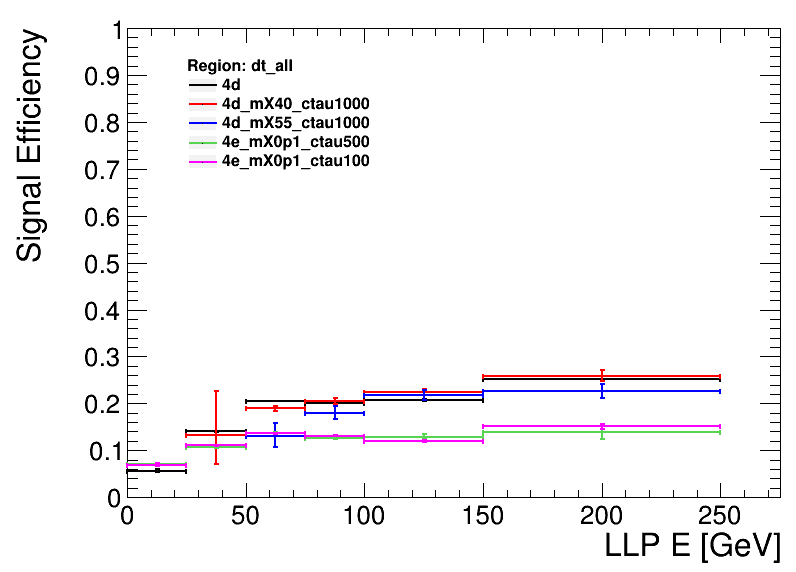

In [13]:
import numpy.ma as ma
import ROOT as rt
import root_numpy
# import importlib
# importlib.reload(sys.modules['histo_utilities'])
# from histo_utilities import std_color_list


for m in llp_e.keys():
    print (m, llp_e[m][0:5], llp_EME[m][0:5], llp_HadE[m][0:5])

numerator = [clusterR,clusterZ,clusterE,clusterPz,clusterEz,clusterGamma, clusterP, clusterEMFracP, clusterEMFracPz, clusterEMFracE, clusterEMFracEz,\
            clusterEMP,clusterEMPz, clusterEME, clusterEMEz,clusterHadP,clusterHadPz,clusterHadE,clusterHadEz,cluster_visFracE, higgsPt_nom, cluster_multiplicity]
denominator = [llp_r,llp_z,llp_e,llp_pz,llp_ez,llp_gamma,llp_p, llp_emfracP, llp_emfracPz, llp_emfracE, llp_emfracEz,\
              llp_EMP,llp_EMPz,llp_EME,llp_EMEz,llp_HadP,llp_HadPz,llp_HadE,llp_HadEz,llp_visFracE, higgsPt_denom,llp_multiplicity]
# bins = [[20,100,700], [35, 550, 1075],  [50,0,500], [50,0,500],[50,0,500],[50,0,100],[50,0,500]]
bins = [[20,100,700], [70, -1275, 1275],  [25,0,500], [25,0,500],[25,0,500],[25,0,100],[25,0,500],[25,0,1], [25,0,1], [25,0,1], [25,0,1],\
       [25,0,500], [25,0,500], [25,0,500], [25,0,500],[25,0,500], [25,0,500], [25,0,500], [25,0,500],[50,0,1]]
bins = [[60,0,700], [70, 400, 1275], [0, 25,50,75,100,150,200,250], [25,0,500],[25,0,500],[25,0,100],[0, 25,50,75,100,150,200,250],[25,0,1], [25,0,1], [100,0,1], [25,0,1],\
       [25,0,500], [25,0,500], [0,25,50,75,100,125,150, 200], [25,0,500],[25,0,500], [25,0,500], [25,0,500], [25,0,500],[20,0,1],[50,0,2000],[100,0,100]]

bins = [[60,0,700], [70, 400, 1275], [0, 25,50,75,100, 150,200,250], [25,0,500],[25,0,500],[25,0,100],[0, 25,50,75,100,150,200,250],[25,0,1], [25,0,1], [100,0,1], [25,0,1],\
       [25,0,500], [25,0,500], [0,25,50,75,100,125,150, 200], [25,0,500],[25,0,500], [25,0,500], [0,25,50,75,100,150,200,250], [25,0,500],[20,0,1],[50,0,2000],[100,0,100]]


bins = [[60,0,700], [70, 400, 1275], [0, 25,50,75,100, 150,250], [25,0,500],[25,0,500],[25,0,100],[0, 25,50,75,100,150,200,250],[25,0,1], [25,0,1], [100,0,1], [25,0,1],\
       [25,0,500], [25,0,500], [0,25,50,75,100,125,150, 200], [25,0,500],[25,0,500], [25,0,500], [0,25,50,75,100,150,200,250], [25,0,500],[20,0,1],[50,0,2000],[100,0,100]]

#L:
bins = [
    [25,0,1000],#0 
    [20, 0, 1000],#1 
    [0, 25,50,75,100, 150,250], #2
    [25,0,500],#3
    [25,0,500],#4
    [25,0,100],#5
    [0, 25,50,75,100,150,200,250],#6
    [25,0,1], #7
    [25,0,1], #8
    [100,0,1], #9
    [25,0,1],#10
    [25,0,500], #11
    [25,0,500], #12
    [0,25,50,75,100,125,150, 200], #13
    [25,0,500],#14
    [25,0,500], #15
    [25,0,500], #16
    [0,25,50,75,100,150,200,250], #17
    [25,0,500],#18
    [20,0,1],#19
    [50,0,2000],#20
    [100,0,100],#21
    ]

xaxis = [
        'LLP decay R [cm]',#0
        'LLP decay Z [cm]',#1
        'LLP E [GeV]',#2
        'LLP p_{Z} [GeV]',#3
        'LLP Ez [GeV]',#4
        'LLP #gamma',#5
        'LLP p [GeV]',#6
        'EM P fraction',#7
        'EM Pz fraction', #8
        'EM E fraction', #9
        'EM Ez fraction',#10
        'EM P', #11
        'EM Pz', #12
        'EM E', #13
        'EM Ez',#14
        'Had P', #15
        'Had Pz', #16
        'Had E', #17
        'Had Ez',#18
        'visible energy fraction',#19
        'higgsPt',#20
        'multiplicity'#21
    ]
varname = [
        'R',#0
        'Z',#1
        'E',#2
        'Pz',#3
        'Ez',#4
        'gamma',#5
        'p',#6
        'EM_P_frac',#7
        'EM_Pz_frac', #8
        'EM_E_frac', #9
        'EM_Ez_frac',#10
        'EM_P', #11
        'EM_Pz', #12
        'EM_E', #13
        'EM_Ez',#14
        'Had_P', #15
        'Had_Pz', #16
        'Had_E', #17
        'Had_Ez',#18
        'visE_frac',#19
        'higgsPt',#20
        'multiplicity'#21
    ]

assert(len(denominator)==len(numerator)==len(bins)==len(xaxis))
index = 2 #LLP E
#index = 13#LLP EM E
#index = 17#LLP Had E
#index = 0 #R
#index = 1 #Z

hm = {}
hb = {}
pEff = {}
c = rt.TCanvas('c','c', 800, 600)
leg = rt.TLegend(0.60,0.15, 0.85,0.35)
leg = rt.TLegend(0.23,0.7,0.43,0.90)
# leg = rt.TLegend(0.7,0.7,0.9,0.9)
leg.SetTextSize(0.03)
leg.SetBorderSize(0)
leg.SetEntrySeparation(0.01)
j = 0
plot_keys = ['4d','4d_mX40_ctau1000','4d_mX55_ctau1000','4e_mX0p1_ctau500','4e_mX0p1_ctau100']
for i, m in enumerate(plot_keys):#enumerate(tree.keys()):
    print(m)
#     
#     if  m == 'HNL':continue
#     if index == 7 and not m == '5':continue
#     if not '15' in m:continue
#     if not 'v2' in m and not 'HNL' in m:continue
#     if not '4Tau_m15_' in m and not 'v2' in m:continue

#     if not '4Tau_m' in m or '10' in m:continue
    #w#if not 'ggH_HToSS_SToPiPlusPiMinus' in m:continue
#     if '10000' in m or '100000' in m or 'dddd' in m:continue
        
#     if not 'm15_10' in m :continue
#     if '10' in m:continue
#     if not m == '4Tau':continue

    print(m)
    ##if not '4d' in m or not '4e' in m: continue
  
    cond = np.abs(cluster_llp_eta[m])<2.4
    cond_b = np.abs(llp_eta[m])<2.4
    
    #region = 'b'
    region = 'dt_all'
    #region = 'MB34'
    #print(numerator[index])
    #print(clusterE[m])
    
    #mb1_rmin = 402
    #mb1_rmax = 450
    #mb2_rmin = 490
    #mb2_rmax = 533
    #mb3_rmin = 597
    #mb3_rmax = 636
    #mb4_rmin = 700
    #mb4_rmax = 738
    #w2_zmin = 407.4
    #w2_zmax = 661
    #w1_zmin = 141.8
    #w1_zmax = 395.4
    #w0_z = 126.8
    
    #MB2,MB3,MB4,MB34
    if region=='MB2':
        cond = np.logical_and(cond, np.abs(clusterR[m])>mb2_rmin)
        cond_b = np.logical_and(cond_b, np.abs(llp_r[m])>mb2_rmin)
        cond = np.logical_and(cond, np.abs(clusterR[m])<mb2_rmax)
        cond_b = np.logical_and(cond_b, np.abs(llp_r[m])<mb2_rmax)
        cond = np.logical_and(cond, np.abs(clusterZ[m])<w2_zmax)
        cond_b = np.logical_and(cond_b, np.abs(llp_z[m])<w2_zmax)
    if region=='MB3':
        cond = np.logical_and(cond, np.abs(clusterR[m])>mb3_rmin)
        cond_b = np.logical_and(cond_b, np.abs(llp_r[m])>mb3_rmin)
        cond = np.logical_and(cond, np.abs(clusterR[m])<mb3_rmax)
        cond_b = np.logical_and(cond_b, np.abs(llp_r[m])<mb3_rmax)
        cond = np.logical_and(cond, np.abs(clusterZ[m])<w2_zmax)
        cond_b = np.logical_and(cond_b, np.abs(llp_z[m])<w2_zmax)    
    if region=='MB4':
        cond = np.logical_and(cond, np.abs(clusterR[m])>mb4_rmin)
        cond_b = np.logical_and(cond_b, np.abs(llp_r[m])>mb4_rmin)
        cond = np.logical_and(cond, np.abs(clusterR[m])<mb4_rmax)
        cond_b = np.logical_and(cond_b, np.abs(llp_r[m])<mb4_rmax)
        cond = np.logical_and(cond, np.abs(clusterZ[m])<w2_zmax)
        cond_b = np.logical_and(cond_b, np.abs(llp_z[m])<w2_zmax)     
    if region=='MB34':
        cond = np.logical_and(cond, np.abs(clusterR[m])>mb3_rmin)
        cond_b = np.logical_and(cond_b, np.abs(llp_r[m])>mb3_rmin)
        cond = np.logical_and(cond, np.abs(clusterR[m])<mb4_rmax)
        cond_b = np.logical_and(cond_b, np.abs(llp_r[m])<mb4_rmax)
        cond = np.logical_and(cond, np.abs(clusterZ[m])<w2_zmax)
        cond_b = np.logical_and(cond_b, np.abs(llp_z[m])<w2_zmax)
    if region=="dt_all":
        cond = np.logical_and(cond, np.abs(clusterR[m])>mb1_rmin)
        cond_b = np.logical_and(cond_b, np.abs(llp_r[m])>mb1_rmin)
        cond = np.logical_and(cond, np.abs(clusterR[m])<mb4_rmax)
        cond_b = np.logical_and(cond_b, np.abs(llp_r[m])<mb4_rmax)
        cond = np.logical_and(cond, np.abs(clusterZ[m])<w2_zmax)
        cond_b = np.logical_and(cond_b, np.abs(llp_z[m])<w2_zmax)
    #if region == 'a':
    #    cond = np.abs(clusterR[m])>390
    #    cond_b = np.abs(llp_r[m])>390
    #    cond = np.logical_and(cond, np.abs(clusterZ[m])<671)
    #    cond_b = np.logical_and(cond_b, np.abs(llp_z[m])<671)
    #    bins = [[60,0,700], [70, 400, 1275], [0, 25,50,75,100, 150,250], [25,0,500],[25,0,500],[25,0,100],[0, 25,50,75,100,150,200,250],[25,0,1], [25,0,1], [100,0,1], [25,0,1],\
    #   [25,0,500], [25,0,500], [0,25,50,75,100,125,150, 200], [25,0,500],[25,0,500], [25,0,500], [0,25,50,75,100,150,200,250], [25,0,500],[20,0,1],[50,0,2000],[100,0,100]]

    #elif region == 'b':
    #    cond = np.abs(clusterZ[m])>671
    #    cond_b = np.abs(llp_z[m])>671
    #    bins = [[60,0,700], [70, 400, 1275], [0, 25,50,75,100, 150,200,250], [25,0,500],[25,0,500],[25,0,100],[0, 25,50,75,100,150,200,250],[25,0,1], [25,0,1], [100,0,1], [25,0,1],\
    #   [25,0,500], [25,0,500], [0,25,50,75,100,125,150, 200], [25,0,500],[25,0,500], [25,0,500], [0,25,50,75,100,150,200,250], [25,0,500],[20,0,1],[50,0,2000],[100,0,100]]
    #bins = [[60,0,700], [70, 400, 1275], [0,10,15,20,25,50,75,100, 150,200,250], [25,0,500],[25,0,500],[25,0,100],[0, 25,50,75,100,150,200,250],[25,0,1], [25,0,1], [100,0,1], [25,0,1],\
    #   [25,0,500], [25,0,500], [0,25,50,75,100,125,150, 200], [25,0,500],[25,0,500], [25,0,500], [0,25,50,75,100,150,200,250], [25,0,500],[20,0,1],[50,0,2000],[100,0,100]]

    print(cluster_llp_eta[m])
    print(llp_eta[m])
    #cond = np.logical_and(cond, np.abs(cluster_llp_eta[m])<2.4)
    #cond_b = np.logical_and(cond_b,np.abs(llp_eta[m])<2.4)
    
    #TODO Here: DT cluster selections applied!
    #cond= np.logical_and(cond, clusterme1112[m]==0)
    #cond= np.logical_and(cond, re12[m]==0)
    #cond= np.logical_and(cond, rb1[m]==0)
    #cond= np.logical_and(cond, mb1[m]==0)
    #cond= np.logical_and(cond, timeSpread[m]<20)
    #cond= np.logical_and(cond, muonVeto[m]<20)
    print(cond)
    print(mb1_hits[m])
    cond= np.logical_and(cond, mb1_hits[m]<=1)
    cond= np.logical_and(cond, rpc_hits[m]>0)
    cond= np.logical_and(cond, mb1_adj_m[m]<=8)
    cond= np.logical_and(cond, mb1_adj_p[m]<=8)
    #cond= np.logical_and(cond, max_station[m]>1)#MB2
    cond= np.logical_and(cond, muonVetoPt[m]<10)
    ##cond= np.logical_and(cond, muonVetoLooseId[m])



    hm[m] = create_TH1D(np.abs(numerator[index][m][cond]), 'l', axis_title = [xaxis[index],'Signal Efficiency'], binning=bins[index])
    hb[m] = create_TH1D(np.abs(denominator[index][m][cond_b]), 'l', axis_title = [xaxis[index],'Signal Efficiency'], binning=bins[index])
    
    pEff[m] = rt.TEfficiency(hm[m],hb[m])
    pEff[m].SetLineColor(std_color_list[j])
    pEff[m].SetLineWidth(2)
    pEff[m].SetMarkerSize(0)
    leg.SetHeader("Region: "+region)
    leg.AddEntry(pEff[m], m)
    pEff[m].Draw('' if j == 0 else 'same')
  

    j+=1

leg.Draw()
c.Draw()


ymax = 0.001
xmax = 0.001
ymin = 10000
xmin = 10000
for m in pEff.keys():
    ymax = max(ymax, pEff[m].GetPaintedGraph().GetHistogram().GetMaximum())
    ymin = min(ymin, pEff[m].GetPaintedGraph().GetHistogram().GetMinimum())
    xmin = min(xmin, pEff[m].GetPaintedGraph().GetHistogram().GetXaxis().GetXmin())
    xmax = max(xmax, pEff[m].GetPaintedGraph().GetHistogram().GetXaxis().GetXmax())
ymin = max(0,ymin)

#w#pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().SetMaximum(ymax)
#w#pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().SetMinimum(ymin)
#w#pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().GetXaxis().SetRangeUser(xmin,xmax)

### pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().SetBins(10,0.,10.)


### leg.Draw()

pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().SetMinimum(0.0)
pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().SetMaximum(1.0)

outDir = "/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/"
file_name = outDir+'SigEff_'+varname[index]+'_region_'+region+'_nRechits'+str(nDt_cut)
c.SaveAs(file_name + '.png')
c.SaveAs(file_name + '.pdf')
c.SaveAs(file_name + '.C')




# Cluster Efficiency Plot (Additional Figure 7)

### produce plot pdf

[210, 101, 174, 379, 161, 202, 289, 207, 187, 108]
n dt cut:  100
verified?  [True, True, True, True, True, True, True, True, True, True]
mask glob:  [True, True, False, True, False, True, False, True, False, True]
[210, 101, 174, 379, 161, 202, 289, 207, 187, 108]
[210, 101, 379, 202, 207, 108, 196, 141, 109, 129]

[210, 101, 174, 379, 161, 202, 289, 207, 187, 108]
n dt cut:  100
verified?  [True, True, True, True, True, True, True, True, True, True]
mask glob:  [False, False, False, False, False, False, False, False, False, True]
[210, 101, 174, 379, 161, 202, 289, 207, 187, 108]
[108, 141, 109, 129, 113, 133, 240, 282, 111, 185]



/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:71: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  ROOT.AsCObject(hist), array, weights, return_indices)
/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:71: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` 

[210, 101, 174, 379, 161, 202, 289, 207, 187, 108]
n dt cut:  100
verified?  [True, True, True, True, True, True, True, True, True, True]
mask glob:  [True, False, False, False, False, False, False, False, False, False]
[210, 101, 174, 379, 161, 202, 289, 207, 187, 108]
[210, 174, 219, 123, 127, 130, 282, 229, 100, 169]

[210, 101, 174, 379, 161, 202, 289, 207, 187, 108]
n dt cut:  100
verified?  [True, True, True, True, True, True, True, True, True, True]
mask glob:  [True, False, False, False, False, False, False, False, False, False]
[210, 101, 174, 379, 161, 202, 289, 207, 187, 108]
[210, 196, 174, 219, 123, 133, 127, 153, 130, 282]



/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:71: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  ROOT.AsCObject(hist), array, weights, return_indices)
/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:71: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` 

[210, 101, 174, 379, 161, 202, 289, 207, 187, 108]
n dt cut:  100
verified?  [True, True, True, True, True, True, True, True, True, True]
mask glob:  [False, False, False, False, False, False, False, False, False, False]
[210, 101, 174, 379, 161, 202, 289, 207, 187, 108]
[112, 105, 315, 247, 112, 132, 148, 122, 260, 128]

[595, 352, 208, 152, 258, 159, 161, 573, 259, 430]
n dt cut:  100
verified?  [True, True, True, True, True, True, True, True, True, True]
mask glob:  [False, False, True, False, False, True, False, True, False, False]
[595, 352, 208, 152, 258, 159, 161, 573, 259, 430]
[208, 159, 573, 139, 183, 120, 341, 216, 117, 307]

[595, 352, 208, 152, 258, 159, 161, 573, 259, 430]
n dt cut:  100
verified?  [True, True, True, True, True, True, True, True, True, True]
mask glob:  [False, False, True, False, False, False, False, False, False, False]
[595, 352, 208, 152, 258, 159, 161, 573, 259, 430]
[208, 183, 341, 216, 150, 277, 190, 136, 119, 291]



...

/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:71: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  ROOT.AsCObject(hist), array, weights, return_indices)
/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:71: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` 

[129, 129, 324, 216, 236, 265, 291, 105, 247, 166]
[129, 317, 268, 260, 281, 248, 182, 249, 124, 112]

[247, 181, 108, 120, 334, 236, 229, 126, 169, 101]
n dt cut:  100
verified?  [True, True, True, True, True, True, True, True, True, True]
mask glob:  [False, False, True, True, True, True, True, False, True, False]
[247, 181, 108, 120, 334, 236, 229, 126, 169, 101]
[108, 120, 334, 236, 229, 169, 148, 361, 212, 146]

[247, 181, 108, 120, 334, 236, 229, 126, 169, 101]
n dt cut:  100
verified?  [True, True, True, True, True, True, True, True, True, True]
mask glob:  [False, False, False, False, False, False, False, False, False, False]
[247, 181, 108, 120, 334, 236, 229, 126, 169, 101]
[227, 136, 155, 204, 268, 161, 128, 103, 170, 147]



/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:71: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  ROOT.AsCObject(hist), array, weights, return_indices)
/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:71: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` 

[247, 181, 108, 120, 334, 236, 229, 126, 169, 101]
n dt cut:  100
verified?  [True, True, True, True, True, True, True, True, True, True]
mask glob:  [False, False, False, False, False, False, False, False, False, False]
[247, 181, 108, 120, 334, 236, 229, 126, 169, 101]
[113, 151, 163, 255, 238, 126, 166, 274, 298, 125]

[247, 181, 108, 120, 334, 236, 229, 126, 169, 101]
n dt cut:  100
verified?  [True, True, True, True, True, True, True, True, True, True]
mask glob:  [False, False, False, True, False, False, True, False, True, False]
[247, 181, 108, 120, 334, 236, 229, 126, 169, 101]
[120, 229, 169, 159, 128, 249, 139, 184, 357, 225]

[247, 181, 108, 120, 334, 236, 229, 126, 169, 101]
n dt cut:  100
verified?  [True, True, True, True, True, True, True, True, True, True]
mask glob:  [False, False, False, False, False, False, False, False, True, False]
[247, 181, 108, 120, 334, 236, 229, 126, 169, 101]
[169, 184, 225, 232, 219, 148, 111, 101, 352, 233]



/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:71: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  ROOT.AsCObject(hist), array, weights, return_indices)
/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:71: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` 

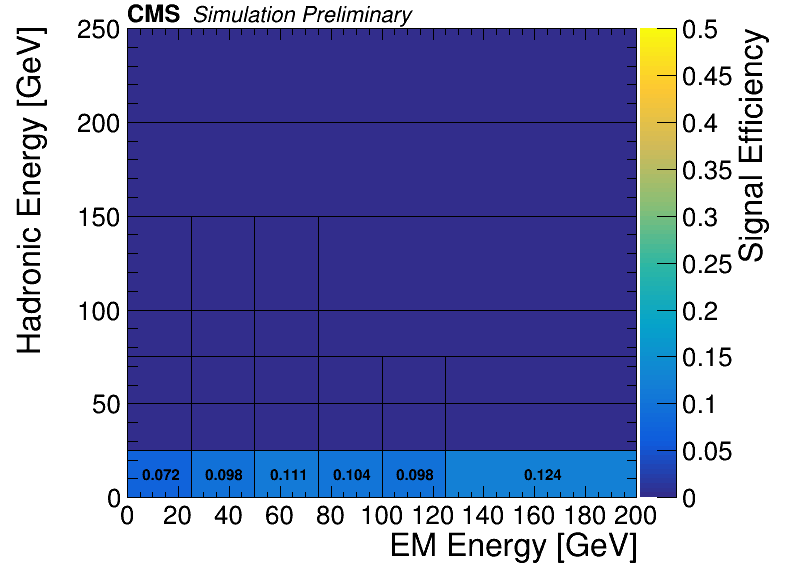

In [55]:

correction = 0.90898
correction = 1
rt.gStyle.SetPaintTextFormat("6.3f")
numerator = [ clusterEME,clusterHadE]
denominator = [llp_EME,llp_HadE]

bins_orig = {
    #'a':[[0, 25,50,100,200], [0, 0,25,50,75,100, 150, 250]], 
    'b':[[0,25,50,75,100,125, 200],  [0,0,25,50,75,100,150,200,250]],
    #'dt_all':[[0,25,50,75,100,125, 200],  [0,0,25,50,75,100,150,200,250]],
    'dt_all':[[0, 25,50,100,200], [0, 0,25,50,75,100, 150, 250]],
}

bins_L = {
    #'a':[[0, 25,50,100,200], [0, 25,50,75,100, 150, 250]], 
    'b':[[0, 25,50,100,200], [0, 25,50,100,250]],
    'dt_all':[[0,25,50,75,100,125, 200],  [0,25,50,75,100,150,200,250]],
    'MB2':[[0,25,50,75,100,125, 200],  [0,25,50,75,100,150,200,250]],
    'MB3':[[0,25,50,75,100,125, 200],  [0,25,50,75,100,150,200,250]],
    'MB4':[[0,25,50,75,100,125, 200],  [0,25,50,75,100,150,200,250]],
    'MB34':[[0,25,50,75,100,125, 200],  [0,25,50,75,100,150,200,250]],
    #'dt_all':[[0, 25, 50, 100, 200], [0, 25, 50, 75, 100, 150, 250] ],
}


bins = bins_L

#bins_plot = {
#    #'a':[[0, 25,50,100,200], [-25, 0,25,50,75,100, 150, 250]],
#    'b':[ [0,25,50,75,100,125, 200],  [-25,0,25,50,75,100,150,200,250]],
#    #'dt_all':[ [0,25,50,75,100,125, 200],  [-25,0,25,50,75,100,150,200,250]],
#    'dt_all':[[0, 25,50,100,200], [-25, 0,25,50,75,100, 150, 250]],
#}

bins_plot = bins_L
xaxis = [ 'EM Energy [GeV]', 'Hadronic Energy [GeV]']

#assert(len(denominator)==len(numerator)==len(bins)==len(xaxis))
assert(len(denominator)==len(numerator)==len(xaxis))

index = [0,1]
hm = {}
hb = {}
pEff = {}
eff_hist = {}
eff_histUp = {}
eff_histDown = {}
h2p = {}
h2pUp = {}
h2pDown = {}



def to_np_pair(x, y):
    # x, y are Awkward 1D after your selections/masks
    # Optional: drop Nones if present
    if ak.any(ak.is_none(x)) or ak.any(ak.is_none(y)):
        x = ak.drop_none(x)
        y = ak.drop_none(y)
    xa = ak.to_numpy(x)
    ya = ak.to_numpy(y)
    # Flatten if needed
    xa = xa.reshape(-1)
    ya = ya.reshape(-1)
    return np.column_stack((xa, ya))


nCsc_cut = 130
nDt_cut = 100
##nDt_cut = 250

regions = ['dt_all','MB2','MB3','MB34','MB4']
#regions = ['dt_all']

for i,m in enumerate(tree.keys()):
    #if not (m == '4d' or m=='4e'):continue
    #if not (m == '4d'):continue
    #if '4d' in m: continue

    c = rt.TCanvas('c','c', 800, 600)

    
    for region in regions:

        bins_temp = bins[region][index[0]]+bins[region][index[1]]+[len(bins[region][index[0]])]+[len(bins[region][index[1]])]
        bins_plot_temp = bins_plot[region][index[0]]+bins_plot[region][index[1]]+[len(bins_plot[region][index[0]])]+[len(bins_plot[region][index[1]])]
        key = m+'_'+region+'_'+str(nDt_cut)

        condm = np.abs(cluster_llp_eta[m])<2.4
        condb = np.abs(llp_eta[m])<2.4

        #MB2,MB3,MB4,MB34
        if region=='MB2':
            condm = np.logical_and(condm, np.abs(clusterR[m])>mb2_rmin)
            condb = np.logical_and(condb, np.abs(llp_r[m])>mb2_rmin)
            condm = np.logical_and(condm, np.abs(clusterR[m])<mb2_rmax)
            condb = np.logical_and(condb, np.abs(llp_r[m])<mb2_rmax)
            condm = np.logical_and(condm, np.abs(clusterZ[m])<w2_zmax)
            condb = np.logical_and(condb, np.abs(llp_z[m])<w2_zmax)
        if region=='MB3':
            condm = np.logical_and(condm, np.abs(clusterR[m])>mb3_rmin)
            condb = np.logical_and(condb, np.abs(llp_r[m])>mb3_rmin)
            condm = np.logical_and(condm, np.abs(clusterR[m])<mb3_rmax)
            condb = np.logical_and(condb, np.abs(llp_r[m])<mb3_rmax)
            condm = np.logical_and(condm, np.abs(clusterZ[m])<w2_zmax)
            condb = np.logical_and(condb, np.abs(llp_z[m])<w2_zmax)    
        if region=='MB4':
            condm = np.logical_and(condm, np.abs(clusterR[m])>mb4_rmin)
            condb = np.logical_and(condb, np.abs(llp_r[m])>mb4_rmin)
            condm = np.logical_and(condm, np.abs(clusterR[m])<mb4_rmax)
            condb = np.logical_and(condb, np.abs(llp_r[m])<mb4_rmax)
            condm = np.logical_and(condm, np.abs(clusterZ[m])<w2_zmax)
            condb = np.logical_and(condb, np.abs(llp_z[m])<w2_zmax)     
        if region=='MB34':
            condm = np.logical_and(condm, np.abs(clusterR[m])>mb3_rmin)
            condb = np.logical_and(condb, np.abs(llp_r[m])>mb3_rmin)
            condm = np.logical_and(condm, np.abs(clusterR[m])<mb4_rmax)
            condb = np.logical_and(condb, np.abs(llp_r[m])<mb4_rmax)
            condm = np.logical_and(condm, np.abs(clusterZ[m])<w2_zmax)
            condb = np.logical_and(condb, np.abs(llp_z[m])<w2_zmax)
        if region=="dt_all":
            condm = np.logical_and(condm, np.abs(clusterR[m])>mb1_rmin)
            condb = np.logical_and(condb, np.abs(llp_r[m])>mb1_rmin)
            condm = np.logical_and(condm, np.abs(clusterR[m])<mb4_rmax)
            condb = np.logical_and(condb, np.abs(llp_r[m])<mb4_rmax)
            condm = np.logical_and(condm, np.abs(clusterZ[m])<w2_zmax)
            condb = np.logical_and(condb, np.abs(llp_z[m])<w2_zmax)
        
        
        condm = np.logical_and(condm, np.abs(cluster_llp_eta[m])<2.4)
        condb = np.logical_and(condb,np.abs(llp_eta[m])<2.4)

        condm = np.logical_and(condm, mb1_hits[m]<=1)
        condm = np.logical_and(condm, rpc_hits[m]>0)
        condm = np.logical_and(condm, mb1_adj_m[m]<=8)
        condm = np.logical_and(condm, mb1_adj_p[m]<=8)
        #condm = np.logical_and(condm, max_station[m]>1)#MB2
        condm = np.logical_and(condm, muonVetoPt[m]<10)
        #condm = np.logical_and(condm, muonVetoLooseId[m]!=1)
        condm = np.logical_and(condm, clusterSize[m]>=nDt_cut)
        print(clusterSize[m][0:10])
        print("n dt cut: ",nDt_cut)
        print("verified? ", (clusterSize[m]>=nDt_cut)[0:10])
        print("mask glob: ",condm[0:10])
        print(clusterSize[m][ clusterSize[m]>=nDt_cut ][0:10])
        print(clusterSize[m][ condm ][0:10])
        
        a_num0 = numerator[index[0]][m][condm]
        a_num1 = numerator[index[1]][m][condm]
        sample_hm = to_np_pair(a_num0, a_num1)


        b_den0 = denominator[index[0]][m][condb]
        b_den1 = denominator[index[1]][m][condb]
        sample_hb = to_np_pair(b_den0, b_den1)

        sample_eff = to_np_pair(a_num0, a_num1)  # numerator again for eff_hist


        
        hm[key] = create_TH2D(
            sample_hm, 'hb1',
            axis_title=[xaxis[index[0]], xaxis[index[1]], 'Signal Efficiency'],
            binning=bins_temp
        )

        hb[key] = create_TH2D(
            sample_hb, 'hb1',
            axis_title=[xaxis[index[0]], xaxis[index[1]], 'Signal Efficiency'],
            binning=bins_temp
        )

        eff_hist[key] = create_TH2D(
            sample_eff, 'hb1',
            axis_title=[xaxis[index[0]], xaxis[index[1]], 'Signal Efficiency'],
            binning=bins_plot_temp
        )
        eff_histUp[key] = eff_hist[key].Clone()
        eff_histDown[key] = eff_hist[key].Clone()
        
        
        pEff[key] = rt.TEfficiency(hm[key],hb[key])
        pEff[key].SetLineWidth(2)
                
        for y in range(1, eff_hist[key].GetYaxis().GetNbins()+1):
                n1 = 0
                n2 = 0
                if y>=6:
                    for x in range(1, eff_hist[key].GetXaxis().GetNbins()+1):
                        n1 += hm[key].GetBinContent(x,y)
                        n2 += hb[key].GetBinContent(x,y)

                for x in range(1, eff_hist[key].GetXaxis().GetNbins()+1):
                    ratio = 0
                    errLow = 0
                    errHigh = 0

                    if (y < 6 and x <= 3) or y <=3:
                        n1 = hm[key].GetBinContent(x,y)
                        n2 = hb[key].GetBinContent(x,y)
                    elif y>=4 and y < 6:
                        n1 = hm[key].GetBinContent(4,y) + hm[key].GetBinContent(5,y) + hm[key].GetBinContent(6,y)
                        n2 = hb[key].GetBinContent(4,y) + hb[key].GetBinContent(5,y) + hb[key].GetBinContent(6,y)
#                         print(x,y)
#                     else:
#                         print(x,y,n1,n2)
                    if n1 > n2: n1 = n2
                    if n2>0:
                        ratio = 1.0 * n1/n2
                        if ratio > 1: ratio = 1
                        errLow = ratio - rt.TEfficiency.ClopperPearson(n2, n1, 0.68269, False);
                        errHigh = rt.TEfficiency.ClopperPearson(n2, n1, 0.68269, True) - ratio
                    eff_histUp[key].SetBinContent(x,y,errHigh*correction)
                    eff_histDown[key].SetBinContent(x,y,errLow*correction)
                    eff_hist[key].SetBinContent(x,y,ratio*correction)

        h2p[key] = rt.TH2Poly()
        h2pUp[key] = rt.TH2Poly()
        h2pDown[key] = rt.TH2Poly()

        bin_counter = 1

        
        for i_y, y in enumerate(bins_plot[region][1]):
            if i_y == len(bins_plot[region][1])-1: 
                continue

            if i_y > 4:
                h2p[key].AddBin(bins_plot[region][0][0], y,
                                     bins_plot[region][0][-1],
                                     bins_plot[region][1][i_y+1])
                h2pUp[key].AddBin(bins_plot[region][0][0], y,
                                       bins_plot[region][0][-1],
                                       bins_plot[region][1][i_y+1])
                h2pDown[key].AddBin(bins_plot[region][0][0], y,
                                         bins_plot[region][0][-1],
                                         bins_plot[region][1][i_y+1])

                val  = eff_hist[key].GetBinContent(1, i_y+1)
                valU = eff_histUp[key].GetBinContent(1, i_y+1)
                valD = eff_histDown[key].GetBinContent(1, i_y+1)

                h2p[key].SetBinContent(bin_counter, val)
                h2pUp[key].SetBinContent(bin_counter, valU)
                h2pDown[key].SetBinContent(bin_counter, valD)

                bin_counter += 1

            else:
                for i_x, x in enumerate(bins_plot[region][0]):
                    if i_x == len(bins_plot[region][0])-1: continue

                    if i_y > 2 and i_x >= 3:
                        if i_x > 3: continue

                        h2p[key].AddBin(x, y,
                                             bins_plot[region][0][-1],
                                             bins_plot[region][1][i_y+1])
                        h2pUp[key].AddBin(x, y,
                                               bins_plot[region][0][-1],
                                               bins_plot[region][1][i_y+1])
                        h2pDown[key].AddBin(x, y,
                                                 bins_plot[region][0][-1],
                                                 bins_plot[region][1][i_y+1])

                        val  = eff_hist[key].GetBinContent(i_x+1, i_y+1)
                        valU = eff_histUp[key].GetBinContent(i_x+1, i_y+1)
                        valD = eff_histDown[key].GetBinContent(i_x+1, i_y+1)

                        h2p[key].SetBinContent(bin_counter, val)
                        h2pUp[key].SetBinContent(bin_counter, valU)
                        h2pDown[key].SetBinContent(bin_counter, valD)

                        bin_counter += 1

                    else:
                        h2p[key].AddBin(x, y,
                                             bins_plot[region][0][i_x+1],
                                             bins_plot[region][1][i_y+1])
                        h2pUp[key].AddBin(x, y,
                                               bins_plot[region][0][i_x+1],
                                               bins_plot[region][1][i_y+1])
                        h2pDown[key].AddBin(x, y,
                                                 bins_plot[region][0][i_x+1],
                                                 bins_plot[region][1][i_y+1])

                        val  = eff_hist[key].GetBinContent(i_x+1, i_y+1)
                        valU = eff_histUp[key].GetBinContent(i_x+1, i_y+1)
                        valD = eff_histDown[key].GetBinContent(i_x+1, i_y+1)

                        h2p[key].SetBinContent(bin_counter, val)
                        h2pUp[key].SetBinContent(bin_counter, valU)
                        h2pDown[key].SetBinContent(bin_counter, valD)

                        bin_counter += 1                            

        h2p[key].SetStats(0)
        h2p[key].ResetStats()
        h2p[key].SetContour(100)
        h2p[key].GetZaxis().SetRangeUser(0.0, 0.5)
        
        for b in  h2p[key].GetBins():
            b.GetPolygon().SetLineWidth(0)

        #if region == 'b':h2p[key].SetMaximum(0.6)
        #else:
        h2p[key].SetMaximum(0.2)
        h2p[key].SetMaximum(0.5)
        h2p[key].SetMinimum(0.0)
        h2p[key].SetMarkerSize(1.4)
        h2p[key].GetXaxis().SetTitle(xaxis[0])
        h2p[key].GetYaxis().SetTitle(xaxis[1])
        h2p[key].GetZaxis().SetTitle('Signal Efficiency')
        h2p[key].Draw('colz text ')
        
        c.SetRightMargin(0.2)
        
        CMS_lumi.cmsText     = "CMS"
        CMS_lumi.writeExtraText = 1
        CMS_lumi.extraText   = "Simulation Supplementary"
        CMS_lumi.extraText   = "Simulation Preliminary"
        CMS_lumi.relPosX = 0.12
        CMS_lumi.CMS_lumi(c, 0, 0)
    
        c.Draw()
        outDir = '/storage/af/user/christiw/gpu/christiw/llp/delayed_jet_analyzer/plots/MuonSystem_Analysis/supplementary/cluster_eff/'+version+'/'
        outDir = "/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/"
        #if not os.path.isdir(outDir): os.makedirs(outDir)
        file_name = outDir+m+'_region_'+region+'_nRechits'+str(nDt_cut)
        
        if correction <1:file_name += '_correction'
        if CMS_lumi.writeExtraText and CMS_lumi.extraText == 'Simulation Preliminary': file_name += "_pas"
        if CMS_lumi.writeExtraText and CMS_lumi.extraText == 'Simulation Supplementary': file_name += "_supplementary"
            
        c.SaveAs(file_name + '.png')
        c.SaveAs(file_name + '.pdf')
        c.SaveAs(file_name + '.C')






### save to ROOT file

In [56]:

outputFileName = '/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/cluster_eff_DT_'+str(nDt_cut)+'_correction.root'
print(outputFileName)

outFile = rt.TFile(outputFileName, 'UPDATE')
for m in eff_hist.keys():
    #if not '4Tau' in m:continue
    #if not ('4d' in m or '4e' in m):continue
    print("outfile for: ",m)
    outFile.WriteTObject(eff_hist[m], 'h_'+m, 'WriteDelete')
    outFile.WriteTObject(eff_histUp[m], 'h_'+m+'Up', 'WriteDelete')
    outFile.WriteTObject(eff_histDown[m], 'h_'+m+'Down', 'WriteDelete')
    outFile.WriteTObject(h2p[m], 'h_poly_'+m, 'WriteDelete')
    outFile.WriteTObject(h2pUp[m], 'h_poly_'+m+'Up', 'WriteDelete')
    outFile.WriteTObject(h2pDown[m], 'h_poly_'+m+'Down', 'WriteDelete')
outFile.Close();

/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/cluster_eff_DT_100_correction.root
outfile for:  4d_dt_all_100
outfile for:  4d_MB2_100
outfile for:  4d_MB3_100
outfile for:  4d_MB34_100
outfile for:  4d_MB4_100
outfile for:  4d_mX55_ctau1000_dt_all_100
outfile for:  4d_mX55_ctau1000_MB2_100
outfile for:  4d_mX55_ctau1000_MB3_100
outfile for:  4d_mX55_ctau1000_MB34_100
outfile for:  4d_mX55_ctau1000_MB4_100
outfile for:  4d_mX40_ctau1000_dt_all_100
outfile for:  4d_mX40_ctau1000_MB2_100
outfile for:  4d_mX40_ctau1000_MB3_100
outfile for:  4d_mX40_ctau1000_MB34_100
outfile for:  4d_mX40_ctau1000_MB4_100
outfile for:  4e_mX0p1_ctau500_dt_all_100
outfile for:  4e_mX0p1_ctau500_MB2_100
outfile for:  4e_mX0p1_ctau500_MB3_100
outfile for:  4e_mX0p1_ctau500_MB34_100
outfile for:  4e_mX0p1_ctau500_MB4_100
outfile for:  4e_mX0p1_ctau100_dt_all_100
outfile for:  4e_mX0p1_ctau100_MB2_100
outfile for:  4e_mX0p1_ctau100_MB3_100
outfile for:  4e_mX0p1_ctau100_MB34_100
outfile for:

### create Y slice (show uncertainty)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/4d_MB2_100nRechits100_bin1.png has been created
Info in <TCanvas::Print>: pdf file /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/4d_MB2_100nRechits100_bin1.pdf has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/4d_MB2_100nRechits100_bin1.C has been generated
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/4d_MB2_100nRechits100_bin2.png has been created
Info in <TCanvas::Print>: pdf file /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/4d_MB2_100nRechits100_bin2.pdf has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src

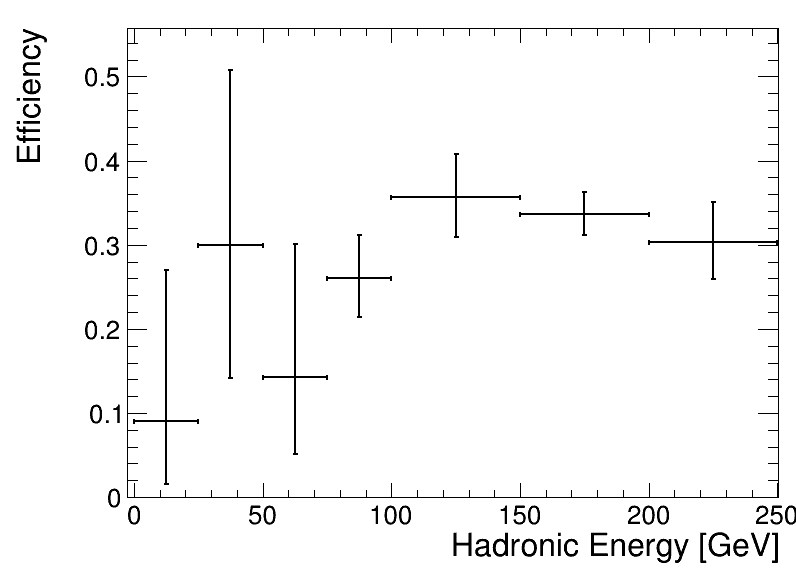

In [57]:
key = '4d_dt_all_100'
key = '4d_MB2_100'

for b in range(1, eff_hist[key].GetNbinsX()+1):
    canvas = rt.TCanvas('c','c', 800, 600)
    nbins = eff_hist[key].GetNbinsY()
    x = []
    y = []
    xErrLow = []
    xErrHigh = []
    yErrLow = []
    yErrHigh = []

    for c in range(nbins):
        x.append(eff_hist[key].GetYaxis().GetBinCenter(c+1))
        xErrLow.append(eff_hist[key].GetYaxis().GetBinCenter(c+1) - eff_hist[key].GetYaxis().GetBinLowEdge(c+1)) 
        xErrHigh.append(eff_hist[key].GetYaxis().GetBinUpEdge(c+1) - eff_hist[key].GetYaxis().GetBinCenter(c+1))

        y.append(eff_hist[key].GetBinContent(b,c+1))
        yErrLow.append(eff_histDown[key].GetBinContent(b,c+1))
        yErrHigh.append(eff_histUp[key].GetBinContent(b,c+1))






    efficiency = rt.TGraphAsymmErrors(nbins, array("d", x), array("d", y), array("d", xErrLow), array("d", xErrHigh),array("d", yErrLow) ,array("d", yErrHigh) )
    efficiency.GetYaxis().SetTitle('Efficiency')

    efficiency.GetXaxis().SetTitle('Hadronic Energy [GeV]')
    efficiency.SetLineWidth(2)
    efficiency.Draw('AP')
    canvas.Draw()


    # efficiency.GetHistogram().SetMaximum(1.0)
    efficiency.GetHistogram().SetMinimum(0.0)
    efficiency.GetHistogram().GetXaxis().SetRangeUser(-25,250)
    canvas.SetRightMargin(0.022)

    canvas.Draw()

    
    outDir = '/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/'
    if not os.path.isdir(outDir): os.makedirs(outDir)    
    file_name = outDir+key+'nRechits'+str(nDt_cut)+'_bin'+str(b)

    canvas.SaveAs(file_name + '.png')
    canvas.SaveAs(file_name + '.pdf')
    canvas.SaveAs(file_name + '.C')






## ratio of 2D efficiency

### check accuracy of signal yield prediction using parameterization vs full-sim preduction (Table 53/54 in AN-19-154)

In [58]:
print(version)

v114


In [60]:
import numpy as np
import awkward as ak
import uproot

# Helper: convert Awkward/NumPy inputs to 1D NumPy arrays
def to_np_1d(a):
    if isinstance(a, ak.Array):
        a = ak.to_numpy(a)
    return np.asarray(a).reshape(-1)

# use the denominator of different samples, find the efficiency in 2D
nCsc_cut = 130
nDt_cut = 100
useJetVeto = False
if useJetVeto:
    source_file1 = uproot.open('/storage/af/user/christiw/gpu/christiw/llp/delayed_jet_analyzer/plots/MuonSystem_Analysis/supplementary/' + version + '/cluster_eff_DT_' + str(nDt_cut) + '_withJetVeto.root')
else:
    source_file1 = uproot.open('/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/cluster_eff_DT_' + str(nDt_cut) + '_correction.root')

wt = {}
observed = {}
wt_err = {}
observed_err = {}
print(tree.keys())

regions = ['dt_all','MB2','MB3','MB34','MB4']

#decays = ['4d','4e','4Tau','4b','4d_mX40_ctau1000','4d_mX55_ctau1000']
decays = ['4d','4d_mX40_ctau1000','4d_mX55_ctau1000','4e_mX0p1_ctau500','4e_mX0p1_ctau100',]
# initialize accumulators for the sources of interest
#for k in ['4Tau']:
for k in decays:
    for region in regions:
        for m in tree.keys():
            wt[k + '_' + region+'_'+m] = 0.0
            observed[k + '_' + region+'_'+m] = 0.0
            wt_err[k + '_' + region+'_'+m] = 0.0
            observed_err[k + '_' + region+'_'+m] = 0.0

#for region in ['dt_all']:
#for region in ['MB2']:
for region in regions:
    #if region != 'b':
    #    continue
    #for source in ['4Tau']:
    for source in decays:
        eff_hist = source_file1[f'h_{source}_{region}_{nDt_cut}']  # uproot Model_TH2D_v4

        # Pre-extract numpy lookup arrays from the histogram
        ret = eff_hist.to_numpy()
        # For TH2, uproot returns (values, xedges, yedges)
        if len(ret) == 3:
            vals, xedges, yedges = ret
        else:
            # Fallback (shouldn't happen for TH2), try to unpack as (values, (xedges, yedges))
            vals, edges = ret
            xedges, yedges = edges

        # Ensure values array is oriented as (nx, ny)
        nx, ny = len(xedges) - 1, len(yedges) - 1
        if vals.shape == (ny, nx):
            vals = vals.T
        elif vals.shape != (nx, ny):
            # As a last resort, try squeezing; then recheck and possibly transpose
            vals = np.squeeze(vals)
            if vals.shape == (ny, nx):
                vals = vals.T
            elif vals.shape != (nx, ny):
                raise RuntimeError(f"Unexpected values shape {vals.shape} for edges (nx, ny)=({nx}, {ny})")

        for m in tree.keys():
            # Prepare x,y inputs for lookup
            xvals = to_np_1d(llp_EME[m])                 # EM energy
            yvals = to_np_1d(np.abs(llp_HadE[m]))        # |Had energy|

            # Compute bin indices with searchsorted
            ix = np.searchsorted(xedges, xvals, side="right") - 1  # 0-based x-bin
            iy = np.searchsorted(yedges, yvals, side="right") - 1  # 0-based y-bin

            # Special-case: y == 0 in first y-bin
            iy[yvals == 0.0] = 0

            # Clip indices to valid bin range (ignore under/overflow)
            ix = np.clip(ix, 0, nx - 1)
            iy = np.clip(iy, 0, ny - 1)

            weight = vals[ix, iy]  # 1D array of weights for events in sample m
            #print(weight)

            # Build masks for numerator/denominator selections (convert to NumPy 1D arrays)
            clusterR_m        = to_np_1d(clusterR[m])
            clusterZ_m        = to_np_1d(clusterZ[m])
            cluster_llp_eta_m = to_np_1d(cluster_llp_eta[m])
            mb1_hits_m        = to_np_1d(mb1_hits[m])
            rpc_hits_m        = to_np_1d(rpc_hits[m])
            mb1_adj_m_m       = to_np_1d(mb1_adj_m[m])
            mb1_adj_p_m       = to_np_1d(mb1_adj_p[m])
            #clusterme1112_m   = to_np_1d(clusterme1112[m])
            #re12_m            = to_np_1d(re12[m])
            #rb1_m            = to_np_1d(rb1[m])
            #mb1_m            = to_np_1d(mb1[m])
            #timeSpread_m      = to_np_1d(timeSpread[m])
            muonVetoPt_m      = to_np_1d(muonVetoPt[m])
            muonVetoLoose_m   = to_np_1d(muonVetoLooseId[m])
            jetVeto_m         = to_np_1d(jetVeto[m]) if useJetVeto else None
            clusterSize_m     = to_np_1d(clusterSize[m])
            max_station_m     = to_np_1d(max_station[m])

            llp_r_m           = to_np_1d(llp_r[m])
            llp_z_m           = to_np_1d(llp_z[m])
            llp_eta_m         = to_np_1d(llp_eta[m])

            condm = np.ones_like(clusterR_m, dtype=bool)
            condb = np.ones_like(llp_r_m, dtype=bool)

            #MB2,MB3,MB4,MB34
            if region=='MB2':
                condm = np.logical_and(condm, np.abs(clusterR_m)>mb2_rmin)
                condb = np.logical_and(condb, np.abs(llp_r_m)>mb2_rmin)
                condm = np.logical_and(condm, np.abs(clusterR_m)<mb2_rmax)
                condb = np.logical_and(condb, np.abs(llp_r_m)<mb2_rmax)
                condm = np.logical_and(condm, np.abs(clusterZ_m)<w2_zmax)
                condb = np.logical_and(condb, np.abs(llp_z_m)<w2_zmax)
            if region=='MB3':
                condm = np.logical_and(condm, np.abs(clusterR_m)>mb3_rmin)
                condb = np.logical_and(condb, np.abs(llp_r_m)>mb3_rmin)
                condm = np.logical_and(condm, np.abs(clusterR_m)<mb3_rmax)
                condb = np.logical_and(condb, np.abs(llp_r_m)<mb3_rmax)
                condm = np.logical_and(condm, np.abs(clusterZ_m)<w2_zmax)
                condb = np.logical_and(condb, np.abs(llp_z_m)<w2_zmax)    
            if region=='MB4':
                condm = np.logical_and(condm, np.abs(clusterR_m)>mb4_rmin)
                condb = np.logical_and(condb, np.abs(llp_r_m)>mb4_rmin)
                condm = np.logical_and(condm, np.abs(clusterR_m)<mb4_rmax)
                condb = np.logical_and(condb, np.abs(llp_r_m)<mb4_rmax)
                condm = np.logical_and(condm, np.abs(clusterZ_m)<w2_zmax)
                condb = np.logical_and(condb, np.abs(llp_z_m)<w2_zmax)     
            if region=='MB34':
                condm = np.logical_and(condm, np.abs(clusterR_m)>mb3_rmin)
                condb = np.logical_and(condb, np.abs(llp_r_m)>mb3_rmin)
                condm = np.logical_and(condm, np.abs(clusterR_m)<mb4_rmax)
                condb = np.logical_and(condb, np.abs(llp_r_m)<mb4_rmax)
                condm = np.logical_and(condm, np.abs(clusterZ_m)<w2_zmax)
                condb = np.logical_and(condb, np.abs(llp_z_m)<w2_zmax)
            if region=="dt_all":
                condm = np.logical_and(condm, np.abs(clusterR_m)>mb1_rmin)
                condb = np.logical_and(condb, np.abs(llp_r_m)>mb1_rmin)
                condm = np.logical_and(condm, np.abs(clusterR_m)<mb4_rmax)
                condb = np.logical_and(condb, np.abs(llp_r_m)<mb4_rmax)
                condm = np.logical_and(condm, np.abs(clusterZ_m)<w2_zmax)
                condb = np.logical_and(condb, np.abs(llp_z_m)<w2_zmax)
            
            condm &= (np.abs(cluster_llp_eta_m) < 2.4)
            condb &= (np.abs(llp_eta_m) < 2.4)

            condm &= (mb1_hits_m<=1)
            condm &= (rpc_hits_m>0)
            condm &= (mb1_adj_m_m<=8)
            condm &= (mb1_adj_p_m<=8)
            #condm &= (max_station_m>1)#MB2
            condm &= (muonVetoPt_m<10)
            ##condm &= (muonVetoLoose_m==1)
            condm &= (clusterSize_m>=nDt_cut)


            if useJetVeto:
                condm &= (jetVeto_m < 10)

            # Accumulate yields and uncertainties
            wt[f'{source}_{region}_{m}']           += np.sum(weight[condb])                  # parameterized prediction
            observed[f'{source}_{region}_{m}']     += np.count_nonzero(condm)                # observed events
            wt_err[f'{source}_{region}_{m}']       += np.sqrt(np.sum(weight[condb]**2))      # quadrature sum
            observed_err[f'{source}_{region}_{m}'] += np.sqrt(np.count_nonzero(condm))       # Poisson

dict_keys(['4d', '4d_mX55_ctau1000', '4d_mX40_ctau1000', '4e_mX0p1_ctau500', '4e_mX0p1_ctau100'])


### print ratio between parameterized and full-simulation signal yield

In [62]:
correction = 0.90898
correction = 1.
#for source in ['4Tau']:
targets = ['4d','4e','4Tau','4b']

targets = ['4d_mX40_ctau1000','4d_mX55_ctau1000']
sources = ['4d_mX40_ctau1000','4d_mX55_ctau1000']
decays = ['4d','4d_mX40_ctau1000','4d_mX55_ctau1000','4e_mX0p1_ctau500','4e_mX0p1_ctau100',]

targets = decays
sources = decays
for source in sources:
#for source in ['4d','4e','4Tau','4b']:
    print("\n")
    print("Derived from: ", source)
    for region in regions:
        print("Region: ",region)
        for target in targets:
            #print(source, region, target)
            n1 = wt[source+'_'+region+'_'+target]
            n2 = correction*observed[source+'_'+region+'_'+target]
            if n2 == 0:continue
            ratio = 1.0*n1/n2
            err = ((wt_err[source+'_'+region+'_'+target]/n1)**2+(correction*observed_err[source+'_'+region+'_'+target]/n2)**2)**0.5*ratio
            print(target, '\t', 'obs: ', round(n2,2), '\t pred: ', round(n1,2) , '\t ratio: ', round(ratio,3), '+/-', round(err,3))




Derived from:  4d
Region:  dt_all
4d 	 obs:  70982.0 	 pred:  70970.49 	 ratio:  1.0 +/- 0.004
4d_mX40_ctau1000 	 obs:  3237.0 	 pred:  3238.01 	 ratio:  1.0 +/- 0.019
4d_mX55_ctau1000 	 obs:  738.0 	 pred:  808.98 	 ratio:  1.096 +/- 0.044
4e_mX0p1_ctau500 	 obs:  7900.0 	 pred:  9406.68 	 ratio:  1.191 +/- 0.014
4e_mX0p1_ctau100 	 obs:  39070.0 	 pred:  44279.65 	 ratio:  1.133 +/- 0.006
Region:  MB2
4d 	 obs:  13250.0 	 pred:  13252.12 	 ratio:  1.0 +/- 0.01
4d_mX40_ctau1000 	 obs:  867.0 	 pred:  622.57 	 ratio:  0.718 +/- 0.029
4d_mX55_ctau1000 	 obs:  183.0 	 pred:  143.41 	 ratio:  0.784 +/- 0.068
4e_mX0p1_ctau500 	 obs:  454.0 	 pred:  1102.27 	 ratio:  2.428 +/- 0.117
4e_mX0p1_ctau100 	 obs:  2608.0 	 pred:  5180.66 	 ratio:  1.986 +/- 0.04
Region:  MB3
4d 	 obs:  10321.0 	 pred:  10326.01 	 ratio:  1.0 +/- 0.011
4d_mX40_ctau1000 	 obs:  472.0 	 pred:  318.47 	 ratio:  0.675 +/- 0.038
4d_mX55_ctau1000 	 obs:  109.0 	 pred:  76.11 	 ratio:  0.698 +/- 0.083
4e_mX0p1_ctau500 	 

/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/ipykernel_launcher.py:24: RuntimeWarning: invalid value encountered in double_scalars


# calculate fraction of events in each region

In [63]:
events = {}
'''
for m in tree.keys():
    events[m] = 0.0
    for region in ['a','b','c']:
        key = m+'_'+region
        if region == 'a':
            condm = np.abs(clusterR[m])>390
            condb = np.abs(llp_r[m])>390
            condm = np.logical_and(condm, np.abs(clusterZ[m])<671)
            condb = np.logical_and(condb, np.abs(llp_z[m])<671)
        elif region == 'b':
            condm = np.abs(clusterZ[m])>671
            condb = np.abs(llp_z[m])>671
        elif region == 'c':
            condm = np.abs(clusterR[m])<270
            condb = np.abs(llp_r[m])<270
            condm = np.logical_and(condm, np.abs(clusterZ[m])<671)
            condb = np.logical_and(condb, np.abs(llp_z[m])<671)

        condm = np.logical_and(condm, np.abs(cluster_llp_eta[m])<2)
        condb = np.logical_and(condb,np.abs(llp_eta[m])<2)


        condm= np.logical_and(condm, clusterme1112[m]==0)
        condm= np.logical_and(condm, re12[m]==0)
        condm= np.logical_and(condm, rb1[m]==0)
        condm= np.logical_and(condm, mb1[m]==0)
        condm= np.logical_and(condm, timeSpread[m]<20)
        condm= np.logical_and(condm, muonVeto[m]<20)
        events[m] += np.count_nonzero(condm)
'''        

regions = ['dt_all','MB2','MB3','MB4','MB1','gap12','gap23','gap34']
for m in tree.keys():
    print("\n")
    print(m)
    events[m] = 0.0

    condr = np.abs(cluster_llp_eta[m])<2.4
    condr = np.logical_and(condr, mb1_hits[m]<=1)
    condr = np.logical_and(condr, rpc_hits[m]>0)
    condr = np.logical_and(condr, mb1_adj_m[m]<=8)
    condr = np.logical_and(condr, mb1_adj_p[m]<=8)
    #condr = np.logical_and(condr, max_station[m]>1)#MB2
    condr = np.logical_and(condr, muonVetoPt[m]<10)
    #condr = np.logical_and(condr, muonVetoLooseId[m]!=1)
    #condr = np.logical_and(condr, clusterSize[m]>=nDt_cut)
        
    events[m] += np.count_nonzero(condr)
    
    print(m, "events tot: ",events[m])
    counter = 0

    for region in regions: 
        #key = m+'_'+region
        #now apply region selections
        #MB2,MB3,MB4,MB34
        if region=='MB1':
            condm = np.logical_and(condr, np.abs(clusterR[m])>mb1_rmin)
            condm = np.logical_and(condm, np.abs(clusterR[m])<mb1_rmax)
            condm = np.logical_and(condm, np.abs(clusterZ[m])<w2_zmax)
            counter+=np.count_nonzero(condm)
        if region=='MB2':
            condm = np.logical_and(condr, np.abs(clusterR[m])>mb2_rmin)
            condm = np.logical_and(condm, np.abs(clusterR[m])<mb2_rmax)
            condm = np.logical_and(condm, np.abs(clusterZ[m])<w2_zmax)
            counter+=np.count_nonzero(condm)
        if region=='MB3':
            condm = np.logical_and(condr, np.abs(clusterR[m])>mb3_rmin)
            condm = np.logical_and(condm, np.abs(clusterR[m])<mb3_rmax)
            condm = np.logical_and(condm, np.abs(clusterZ[m])<w2_zmax)
            counter+=np.count_nonzero(condm)
        if region=='MB4':
            condm = np.logical_and(condr, np.abs(clusterR[m])>mb4_rmin)
            condm = np.logical_and(condm, np.abs(clusterR[m])<mb4_rmax)
            condm = np.logical_and(condm, np.abs(clusterZ[m])<w2_zmax)
            counter+=np.count_nonzero(condm)
        if region=='MB34':
            condm = np.logical_and(condr, np.abs(clusterR[m])>mb3_rmin)
            condm = np.logical_and(condm, np.abs(clusterR[m])<mb4_rmax)
            condm = np.logical_and(condm, np.abs(clusterZ[m])<w2_zmax)
        if region=="dt_all":
            condm = np.logical_and(condr, np.abs(clusterR[m])>mb1_rmin)
            condm = np.logical_and(condm, np.abs(clusterR[m])<mb4_rmax)
            condm = np.logical_and(condm, np.abs(clusterZ[m])<w2_zmax)
        if region=='gap12':
            condm = np.logical_and(condr, np.abs(clusterR[m])<mb2_rmin)
            condm = np.logical_and(condm, np.abs(clusterR[m])>mb1_rmax)
            counter+=np.count_nonzero(condm)
        if region=='gap23':
            condm = np.logical_and(condr, np.abs(clusterR[m])<mb3_rmin)
            condm = np.logical_and(condm, np.abs(clusterR[m])>mb2_rmax)
            counter+=np.count_nonzero(condm)
        if region=='gap34':
            condm = np.logical_and(condr, np.abs(clusterR[m])<mb4_rmin)
            condm = np.logical_and(condm, np.abs(clusterR[m])>mb3_rmax)
            counter+=np.count_nonzero(condm)
        
        
        print(region, '\t events: ', np.count_nonzero(condm),'\t ratio: ', np.count_nonzero(condm)/events[m])
    print("summing MB2+3+4 and gaps: ",counter)



4d
4d events tot:  70982.0
dt_all 	 events:  70982 	 ratio:  1.0
MB2 	 events:  13250 	 ratio:  0.18666704234876447
MB3 	 events:  10321 	 ratio:  0.14540305993068664
MB4 	 events:  4672 	 ratio:  0.06581950353610774
MB1 	 events:  855 	 ratio:  0.012045307260995746
gap12 	 events:  12943 	 ratio:  0.18234200219774027
gap23 	 events:  18527 	 ratio:  0.26100983347891016
gap34 	 events:  10414 	 ratio:  0.14671325124679496
summing MB2+3+4 and gaps:  70982


4d_mX55_ctau1000
4d_mX55_ctau1000 events tot:  738.0
dt_all 	 events:  738 	 ratio:  1.0
MB2 	 events:  183 	 ratio:  0.24796747967479674
MB3 	 events:  109 	 ratio:  0.14769647696476965
MB4 	 events:  30 	 ratio:  0.04065040650406504
MB1 	 events:  1 	 ratio:  0.0013550135501355014
gap12 	 events:  130 	 ratio:  0.17615176151761516
gap23 	 events:  191 	 ratio:  0.2588075880758808
gap34 	 events:  94 	 ratio:  0.12737127371273713
summing MB2+3+4 and gaps:  738


4d_mX40_ctau1000
4d_mX40_ctau1000 events tot:  3237.0
dt_all 	 events